-------------------------------------------------

# Part 1: Data Backghround

-----------

# Part 2: Research Question

### Which combination of mobile phone features has the greatest impact on determining its price?

### Research Goal: Recommend effective price-featured phones for users.

-------------------------------------------------

# Part 3: Data Analysis

## 1. Import Libraries

In [1]:
import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

-------------------------------------------------

## 2. Read Dataset - Heewon Yang

In [2]:
df = pd.read_csv('smartphones.csv')

In [3]:
df.head()

,brand_name,model,price,avg_rating,5G_or_not,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging_available,...,internal_memory,screen_size,refresh_rate,num_rear_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,resolution_height,resolution_width
0,apple,Apple iPhone 11,38999,7.3,0,bionic,6.0,2.65,3110.0,0,...,64,6.1,60,2,ios,12.0,12.0,0,1792,828
1,apple,Apple iPhone 11 (128GB),46999,7.5,0,bionic,6.0,2.65,3110.0,0,...,128,6.1,60,2,ios,12.0,12.0,0,1792,828
2,apple,Apple iPhone 11 Pro Max,109900,7.7,0,bionic,6.0,2.65,3500.0,1,...,64,6.5,60,3,ios,12.0,12.0,0,2688,1242
3,apple,Apple iPhone 12,51999,7.4,1,bionic,6.0,3.10,NaN,0,...,64,6.1,60,2,ios,12.0,12.0,0,2532,1170
4,apple,Apple iPhone 12 (128GB),55999,7.5,1,bionic,6.0,3.10,NaN,0,...,128,6.1,60,2,ios,12.0,12.0,0,2532,1170


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 980 non-null    object 
 1   model                      980 non-null    object 
 2   price                      980 non-null    int64  
 3   avg_rating                 879 non-null    float64
 4   5G_or_not                  980 non-null    int64  
 5   processor_brand            960 non-null    object 
 6   num_cores                  974 non-null    float64
 7   processor_speed            938 non-null    float64
 8   battery_capacity           969 non-null    float64
 9   fast_charging_available    980 non-null    int64  
 10  fast_charging              769 non-null    float64
 11  ram_capacity               980 non-null    int64  
 12  internal_memory            980 non-null    int64  
 13  screen_size                980 non-null    float64

In [5]:
# count NA values of each columns
count_na = df.isna().sum()
count_na

brand_name                     0
model                          0
price                          0
avg_rating                   101
5G_or_not                      0
processor_brand               20
num_cores                      6
processor_speed               42
battery_capacity              11
fast_charging_available        0
fast_charging                211
ram_capacity                   0
internal_memory                0
screen_size                    0
refresh_rate                   0
num_rear_cameras               0
os                            14
primary_camera_rear            0
primary_camera_front           5
extended_memory_available      0
resolution_height              0
resolution_width               0
dtype: int64

-------------------------------

## 2-2. Update dataset - Heewon Yang
Fill out data loss

In [6]:
df = pd.read_csv('smartphones_updated.csv')
count_na = df.isna().sum()
count_na

brand_name                     0
model                          0
price                          0
avg_rating                    98
5G_or_not                      0
processor_brand               20
num_cores                      6
processor_speed               42
battery_capacity               1
fast_charging_available        0
fast_charging                211
ram_capacity                   0
internal_memory                0
screen_size                    0
refresh_rate                   0
num_rear_cameras               0
os                            14
primary_camera_rear            0
primary_camera_front           5
extended_memory_available      0
resolution_height              0
resolution_width               0
dtype: int64

In [7]:
df = df.drop('fast_charging', axis=1)

------------

## 3. Data Wrangling & Basic Analysis 

------------

### [Part 1: Filter out NA values & Outliers] - Heewon Yang

In [8]:
brand_count = df['brand_name'].value_counts()
brand_count[brand_count >= 10]

brand_name
xiaomi      134
samsung     132
vivo        111
realme       97
oppo         88
motorola     52
apple        46
oneplus      42
poco         41
tecno        33
iqoo         32
infinix      29
huawei       16
google       14
honor        13
nokia        13
itel         10
Name: count, dtype: int64

* Top 5 brands
* https://www.visualcapitalist.com/the-top-companies-by-global-smartphone-market-share/

In [9]:
# Filter brand_model to focus on popular mobile phone brands.
df = df[df['brand_name'].isin(
    ["samsung", "apple", "xiaomi", "vivo", "oppo"])]

> #### Drop columns that have too much NA

In [10]:
count_na = df.isna().sum()
count_na

brand_name                    0
model                         0
price                         0
avg_rating                   48
5G_or_not                     0
processor_brand              11
num_cores                     5
processor_speed              31
battery_capacity              1
fast_charging_available       0
ram_capacity                  0
internal_memory               0
screen_size                   0
refresh_rate                  0
num_rear_cameras              0
os                            5
primary_camera_rear           0
primary_camera_front          2
extended_memory_available     0
resolution_height             0
resolution_width              0
dtype: int64

In [11]:
df = df.drop('avg_rating', axis=1)

> #### Drop price outliers

In [12]:
df['price'].sort_values(ascending=False)

909    480000
873    199990
32     182999
19     179900
29     172999
        ...  
901      6999
903      6499
558      6499
906      6171
555      4999
Name: price, Length: 511, dtype: int64

In [13]:
df = df.drop(index=909)

In [14]:
df['price'].sort_values(ascending=False)

873    199990
32     182999
19     179900
29     172999
34     169900
        ...  
901      6999
903      6499
558      6499
906      6171
555      4999
Name: price, Length: 510, dtype: int64

In [15]:
df.to_csv('filtered_data.csv', index=False)

(+ Fill out more data)
https://browser.geekbench.com/ios_devices/iphone-xr

In [16]:
df = pd.read_csv('filtered_data_updated.csv')

-------------

### [Part 2: Create new columns] Hojae Song

In [17]:
df = pd.read_csv('filtered_data_updated.csv')
# Filter brand_model to focus on popular mobile phone brands.
df = df[df['brand_name'].isin(
    ["samsung", "apple", "xiaomi", "vivo", "oppo"])]

In [18]:
# Calculate pixel count: (height × width)
df['screen_resolution'] = df['resolution_height'] * df['resolution_width']

In [19]:
# Calculate pixel density (ppi)
df['ppi'] = np.sqrt(df['resolution_height']**2 + df['resolution_width']**2) / df['screen_size']

-------------------------

### [Part 3: Price cost Low vs High ] - Heewon Yang

In [20]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['price'] = df['price'] / 100

print(df['price'].dtype)

float64


In [21]:
# Calculate price thresholds
low_threshold = df['price'].quantile(0.333) # 33.3%
high_threshold = df['price'].quantile(0.667) #66.7%
max = df['price'].quantile(0.9) #100%
# Print thresholds
print(f"Max Price Threshold: {max}")
print(f"Low Price Threshold: {low_threshold}")
print(f"Mid Price Range: {low_threshold} to {high_threshold}")
print(f"High Price Threshold: above {high_threshold}")

Max Price Threshold: 849.918
Low Price Threshold: 159.98164
Mid Price Range: 159.98164 to 299.99
High Price Threshold: above 299.99


In [22]:
# Define function to categorize prices
def price_level (price):
    if price <= low_threshold:
        return 'Low'
    elif price <= high_threshold:
        return 'Mid'
    else:
        return 'High'

# Apply the function to create a new column
df['price_category'] = df['price'].apply(price_level)

In [23]:
# Separate dataframe
df_low = df[df['price_category'] == 'Low']
df_mid = df[df['price_category'] == 'Mid']
df_high = df[df['price_category'] == 'High']

-----------------------

### [Part 4: Categorical variables analysis]

> ### Jaemin Kim

In [24]:
# Filter out categorical features
df_categorical = df[['brand_name','model','processor_brand','os']].astype(str) # categories

# Calculate number of unique values and unique values for each feature
unique_counts = df_categorical.nunique()
unique_values = df_categorical.apply(lambda x: x.unique())

# Create new dataframe with the results
pd.DataFrame({'Number of Unique Values': unique_counts, 'Unique Values': unique_values})

,Number of Unique Values,Unique Values
brand_name,5,"[xiaomi, apple, samsung, oppo, vivo]"
model,509,"[Xiaomi Mi Mix Alpha, Apple iPhone 14 Pro Max ..."
processor_brand,9,"[snapdragon, bionic, exynos, dimensity, fusion..."
os,4,"[android, ios, other, nan]"


> ### Heewon Yang

In [25]:
# Function to perform categorical analysis
def categorical_analysis(df):
    categorical_features = ['brand_name', 'model', 'processor_brand', 'os']
    df_categorical = df[categorical_features]
    unique_counts = df_categorical.nunique()  # Unique counts for each category
    unique_values = df_categorical.apply(lambda x: x.unique())  # List of unique values
    
    return pd.DataFrame({'Number of Unique Values': unique_counts, 'Unique Values': unique_values})

In [26]:
# Heewon Yang
# Categorical analysis by price level
cat_low = categorical_analysis(df_low)
cat_mid = categorical_analysis(df_mid)
cat_high = categorical_analysis(df_high)

In [27]:
cat_low

,Number of Unique Values,Unique Values
brand_name,4,"[oppo, samsung, vivo, xiaomi]"
model,170,"[OPPO A77 (4GB RAM + 128 GB), OPPO A73, Samsun..."
processor_brand,6,"[helio, nan, exynos, snapdragon, dimensity, un..."
os,1,[android]


In [28]:
cat_mid

,Number of Unique Values,Unique Values
brand_name,5,"[vivo, xiaomi, apple, oppo, samsung]"
model,171,"[Vivo S1 Pro, Vivo V21s, Xiaomi Civi 2, Xiaomi..."
processor_brand,5,"[snapdragon, dimensity, bionic, exynos, helio,..."
os,2,"[android, ios]"


In [29]:
cat_high

,Number of Unique Values,Unique Values
brand_name,5,"[xiaomi, apple, samsung, oppo, vivo]"
model,168,"[Xiaomi Mi Mix Alpha, Apple iPhone 14 Pro Max ..."
processor_brand,5,"[snapdragon, bionic, exynos, dimensity, fusion]"
os,3,"[android, ios, other, nan]"


-------------------------

### [Part 5: Numeric (Quantitative) variables analysis: Continuous vs Binary] - Heewon Yang

> #### 1. Continuous Variables

In [30]:
# Define a function for numeric analysis
def continuous_analysis(df):
    # Select only numeric columns
    continuous_columns = [
        "price", "num_cores", "processor_speed", "battery_capacity",
        "ram_capacity", "internal_memory", "screen_size", "refresh_rate",
        "num_rear_cameras", "primary_camera_rear", "primary_camera_front",
        "resolution_width", "resolution_height",
        "screen_resolution", "ppi"
    ]
    
    # Calculate correlations
    continuous_df = df[continuous_columns]
    correlation_features = continuous_df.corr()['price']
    
    # Get the top 10 features by absolute correlation
    top_5 = correlation_features.abs().sort_values(ascending=False).head(5)
    return top_5

In [31]:
# Perform numeric analysis for each price category
conti_low = continuous_analysis(df_low)
conti_mid = continuous_analysis(df_mid)
conti__high = continuous_analysis(df_high)

In [32]:
# Display results
print("Low Price Category Continuous Analysis:\n", conti_low)
print("\nMid Price Category Continuous Analysis:\n", conti_mid)
print("\nHigh Price Category Continuous Analysis:\n", conti__high)

Low Price Category Continuous Analysis:
 price                   1.000000
internal_memory         0.630188
primary_camera_rear     0.598361
ram_capacity            0.579865
primary_camera_front    0.471498
Name: price, dtype: float64

Mid Price Category Continuous Analysis:
 price                   1.000000
primary_camera_front    0.425614
processor_speed         0.405262
ram_capacity            0.377092
internal_memory         0.349251
Name: price, dtype: float64

High Price Category Continuous Analysis:
 price                1.000000
internal_memory      0.599889
resolution_width     0.525857
processor_speed      0.504342
screen_resolution    0.417543
Name: price, dtype: float64


> #### 2. Binary Variables

In [33]:
def binary_analysis(df, binary_columns):
    results = {}
    for col in binary_columns:
        counts = df[col].value_counts()  # Count 0 and 1
        results[col] = {'0 (No)': counts.get(0, 0), '1 (Yes)': counts.get(1, 0)}
    return pd.DataFrame(results).T

In [34]:
# Binary columns to analyze
binary_columns = ['5G_or_not', 'fast_charging_available', 'extended_memory_available']

# Perform binary analysis for each category
binary_low = binary_analysis(df_low, binary_columns)
binary_mid = binary_analysis(df_mid, binary_columns)
binary_high = binary_analysis(df_high, binary_columns)

# Add a column to indicate the price category
binary_low['Price Category'] = 'Low'
binary_mid['Price Category'] = 'Mid'
binary_high['Price Category'] = 'High'

In [35]:
binary_low

,0 (No),1 (Yes),Price Category
5G_or_not,149,21,Low
fast_charging_available,45,125,Low
extended_memory_available,6,164,Low


In [36]:
binary_mid

,0 (No),1 (Yes),Price Category
5G_or_not,55,116,Mid
fast_charging_available,7,164,Mid
extended_memory_available,36,135,Mid


In [37]:
binary_high

,0 (No),1 (Yes),Price Category
5G_or_not,18,150,High
fast_charging_available,14,154,High
extended_memory_available,136,32,High


-----------------------

## 4. Data Visualization (EDA)

### [Part 1: Basic Visualization] - Hyukjoon Choi

> ### 1. Histograms

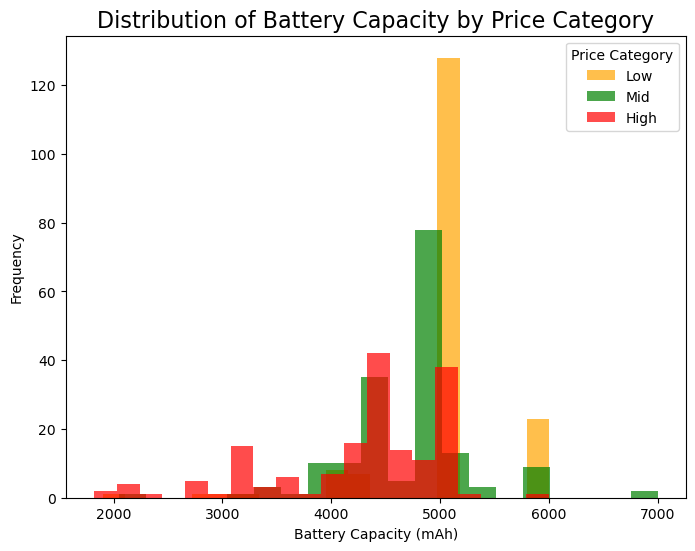

In [38]:
plt.figure(figsize=(8, 6))

# Histogram Low price
plt.hist(df_low['battery_capacity'], bins=20, alpha=0.7, label='Low', color='orange')

# Histogram Mid price
plt.hist(df_mid['battery_capacity'], bins=20, alpha=0.7, label='Mid', color='green')

# Histogram High price
plt.hist(df_high['battery_capacity'], bins=20, alpha=0.7, label='High', color='red')

plt.title("Distribution of Battery Capacity by Price Category", fontsize=16)
plt.xlabel("Battery Capacity (mAh)")
plt.ylabel("Frequency")
plt.legend(title='Price Category')
plt.show()

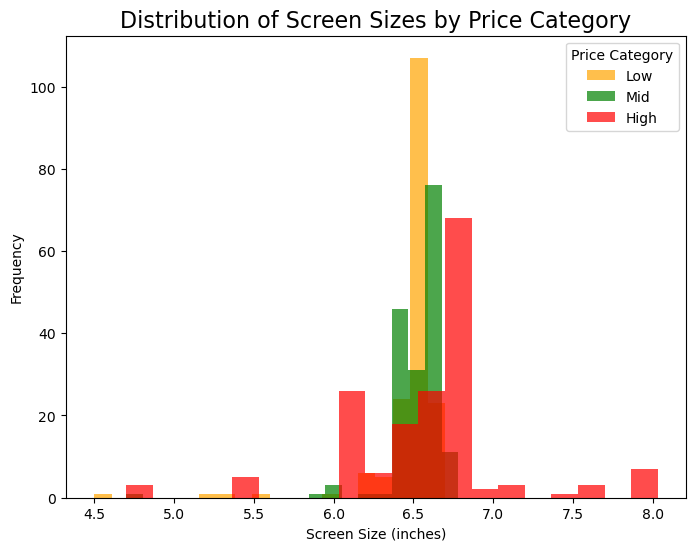

In [39]:
plt.figure(figsize=(8, 6))

# Histogram for Low price category
plt.hist(df_low['screen_size'], bins=20, alpha=0.7, label='Low', color='orange')

# Histogram for Mid price category
plt.hist(df_mid['screen_size'], bins=20, alpha=0.7, label='Mid', color='green')

# Histogram for High price category
plt.hist(df_high['screen_size'], bins=20, alpha=0.7, label='High', color='red')

# Add title and labels
plt.title("Distribution of Screen Sizes by Price Category", fontsize=16)
plt.xlabel("Screen Size (inches)")
plt.ylabel("Frequency")
plt.legend(title='Price Category')

# Show the plot
plt.show()

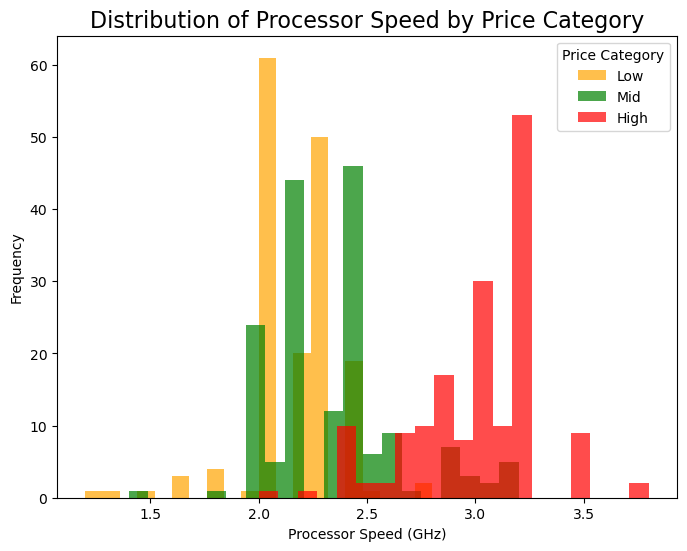

In [40]:
plt.figure(figsize=(8, 6))

# Histogram for Low price category
plt.hist(df_low['processor_speed'], bins=20, alpha=0.7, label='Low', color='orange')

# Histogram for Mid price category
plt.hist(df_mid['processor_speed'], bins=20, alpha=0.7, label='Mid', color='green')

# Histogram for High price category
plt.hist(df_high['processor_speed'], bins=20, alpha=0.7, label='High', color='red')

# Add title and labels
plt.title("Distribution of Processor Speed by Price Category", fontsize=16)
plt.xlabel("Processor Speed (GHz)")
plt.ylabel("Frequency")
plt.legend(title='Price Category')

# Show the plot
plt.show()

> ### 2. Bar charts

C:\Users\HEEWON\AppData\Local\Temp\ipykernel_19472\2415077055.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='brand_name', data=df, order=df['brand_name'].value_counts().index, palette='mako')


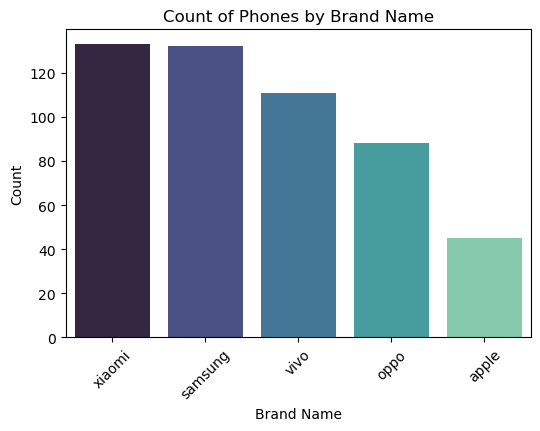

In [60]:
plt.figure(figsize=(6, 4))
sns.countplot(x='brand_name', data=df, order=df['brand_name'].value_counts().index, palette='mako')
plt.title("Count of Phones by Brand Name")
plt.xlabel("Brand Name")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

C:\Users\HEEWON\AppData\Local\Temp\ipykernel_19472\427157594.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='processor_brand', data=df, palette='Blues')


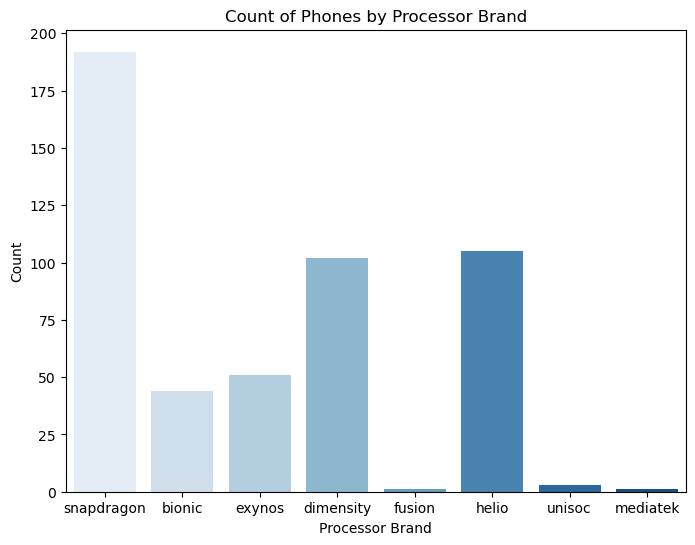

In [61]:
plt.figure(figsize=(8, 6))
sns.countplot(x='processor_brand', data=df, palette='Blues')
plt.title("Count of Phones by Processor Brand")
plt.xlabel("Processor Brand")
plt.ylabel("Count")
plt.show()

> ### 3. Scatterplots

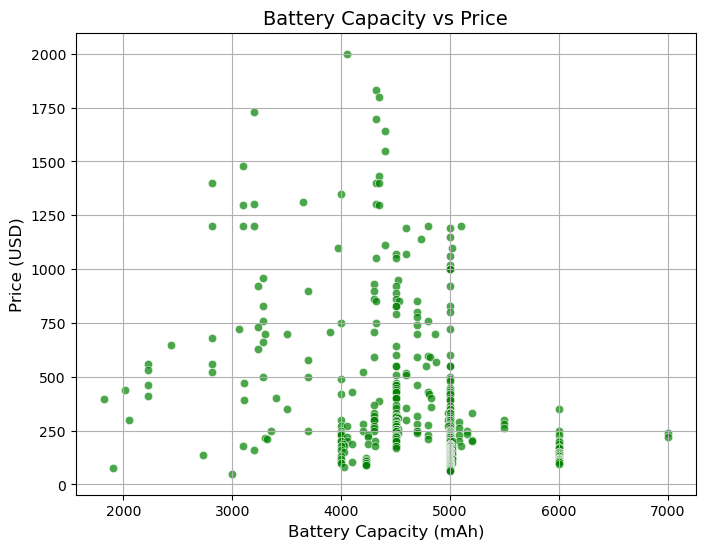

In [62]:
# Battery Capacity vs Price (Scatter Plot)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='battery_capacity', y='price', data=df, alpha=0.7, color='green')
plt.title('Battery Capacity vs Price', fontsize=14)
plt.xlabel('Battery Capacity (mAh)', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.grid()
plt.show()

> ### 4. Boxplots & Violineplot

C:\Users\HEEWON\AppData\Local\Temp\ipykernel_19472\3039821395.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='os', y='price', data=df, palette='Set3')


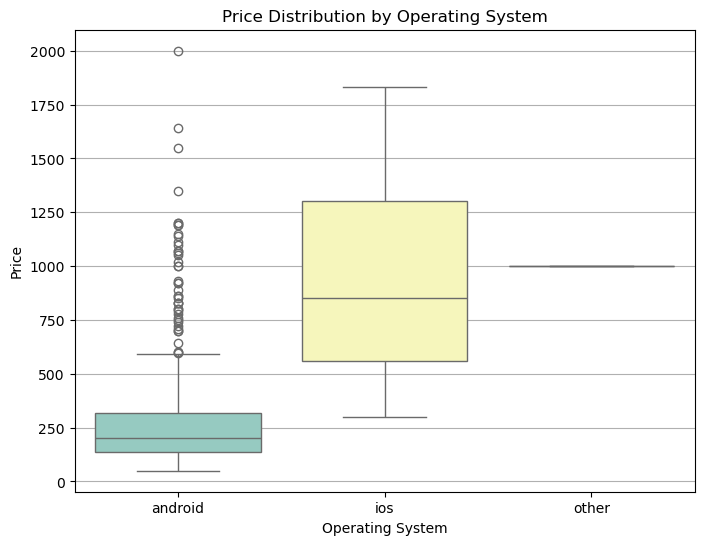

In [63]:
# Boxplot: OS vs Price
plt.figure(figsize=(8, 6))
sns.boxplot(x='os', y='price', data=df, palette='Set3')
plt.title("Price Distribution by Operating System")
plt.xlabel("Operating System")
plt.ylabel("Price")
plt.grid(axis='y')
plt.show()

C:\Users\HEEWON\AppData\Local\Temp\ipykernel_19472\147991932.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='5G_or_not', y='price', data=df, palette='Set2')


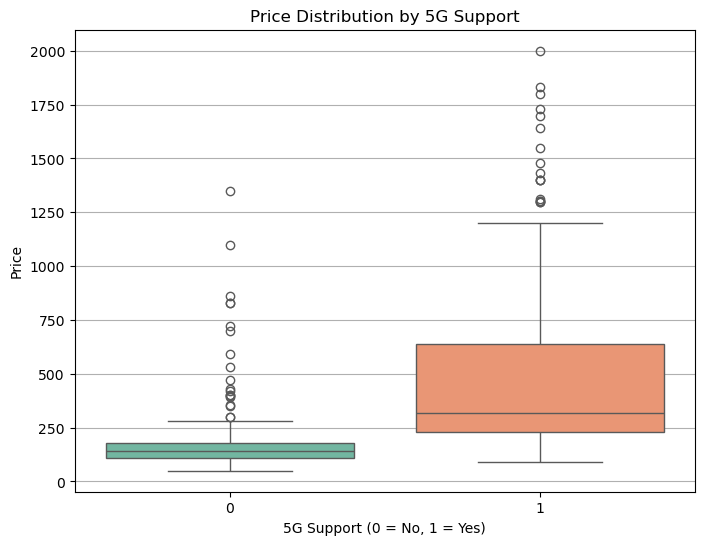

In [64]:
# Boxplot: 5G Support vs Price
plt.figure(figsize=(8, 6))
sns.boxplot(x='5G_or_not', y='price', data=df, palette='Set2')
plt.title("Price Distribution by 5G Support")
plt.xlabel("5G Support (0 = No, 1 = Yes)")
plt.ylabel("Price")
plt.grid(axis='y')
plt.show()


C:\Users\HEEWON\AppData\Local\Temp\ipykernel_19472\3444537665.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='internal_memory', y='price', data=df, palette='cool')


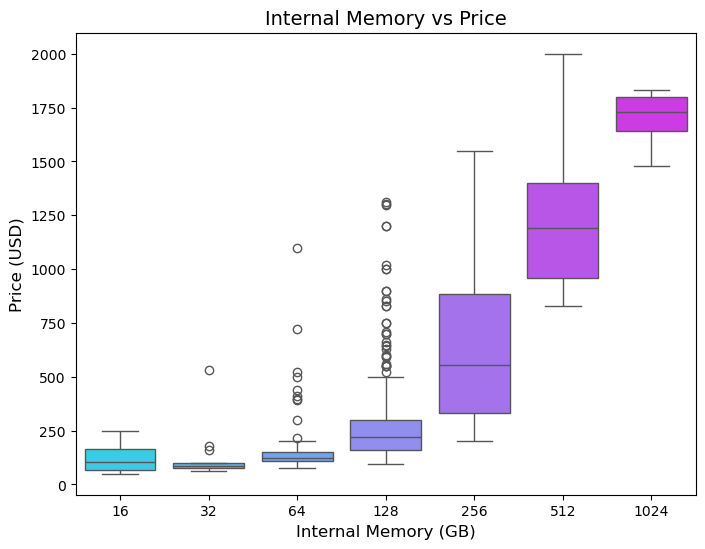

In [65]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='internal_memory', y='price', data=df, palette='cool')
plt.title('Internal Memory vs Price', fontsize=14)
plt.xlabel('Internal Memory (GB)', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.show()

C:\Users\HEEWON\AppData\Local\Temp\ipykernel_19472\3883398032.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ram_capacity', y='price', data=df, palette='viridis')


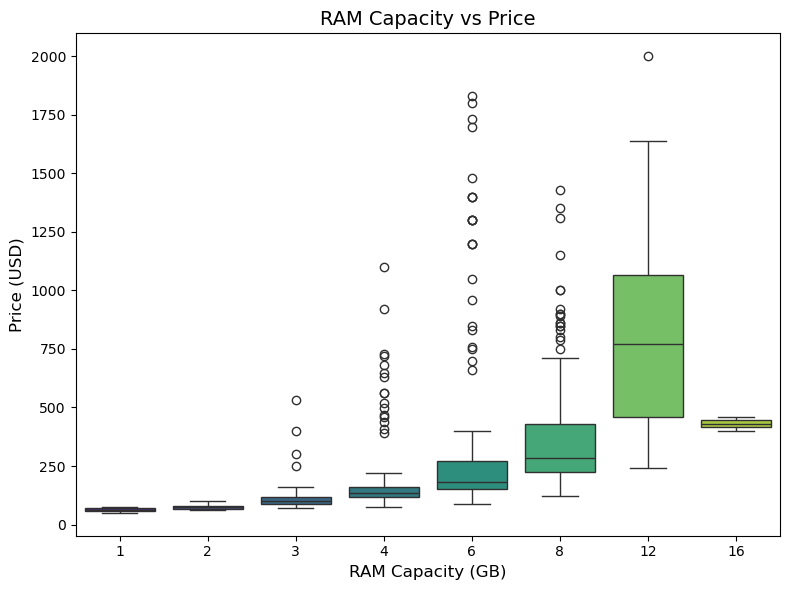

In [66]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='ram_capacity', y='price', data=df, palette='viridis')
plt.title('RAM Capacity vs Price', fontsize=14)
plt.xlabel('RAM Capacity (GB)', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.tight_layout()
plt.show()

> ### 6. Density plot

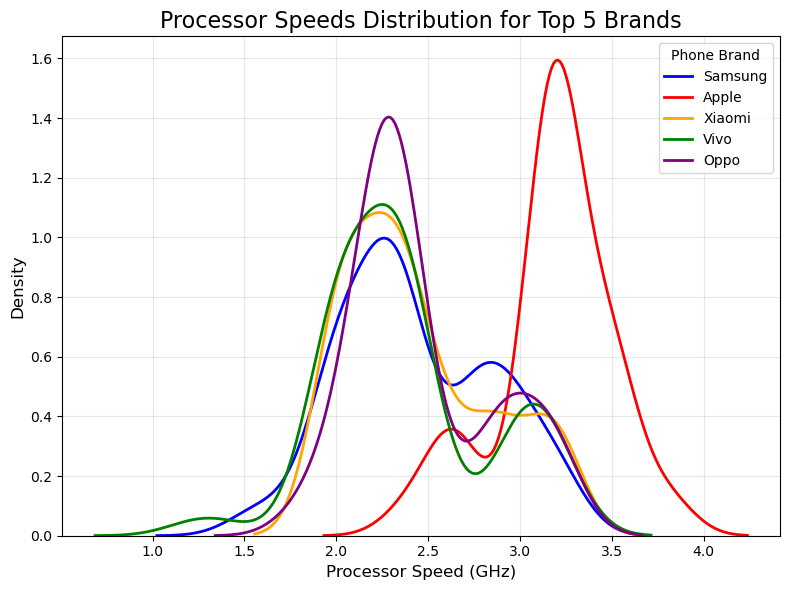

In [67]:
plt.figure(figsize=(8, 6))

# Line plot for KDE of each brand
sns.kdeplot(
    data=df[df['brand_name'] == 'samsung'],
    x='processor_speed',
    label='Samsung',
    color='blue',
    linewidth=2
)
sns.kdeplot(
    data=df[df['brand_name'] == 'apple'],
    x='processor_speed',
    label='Apple',
    color='red',
    linewidth=2
)
sns.kdeplot(
    data=df[df['brand_name'] == 'xiaomi'],
    x='processor_speed',
    label='Xiaomi',
    color='orange',
    linewidth=2
)
sns.kdeplot(
    data=df[df['brand_name'] == 'vivo'],
    x='processor_speed',
    label='Vivo',
    color='green',
    linewidth=2
)
sns.kdeplot(
    data=df[df['brand_name'] == 'oppo'],
    x='processor_speed',
    label='Oppo',
    color='purple',
    linewidth=2
)

# Add titles, labels, and legend
plt.title("Processor Speeds Distribution for Top 5 Brands", fontsize=16)
plt.xlabel("Processor Speed (GHz)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(title="Phone Brand", loc='upper right')
plt.grid(alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

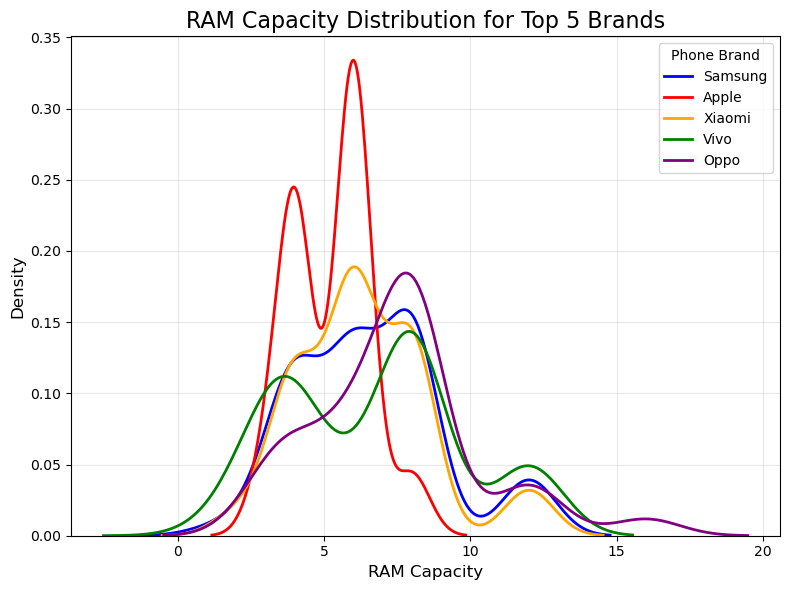

In [68]:
plt.figure(figsize=(8, 6))

# Line plot for KDE of each brand
sns.kdeplot(
    data=df[df['brand_name'] == 'samsung'],
    x='ram_capacity',
    label='Samsung',
    color='blue',
    linewidth=2
)
sns.kdeplot(
    data=df[df['brand_name'] == 'apple'],
    x='ram_capacity',
    label='Apple',
    color='red',
    linewidth=2
)
sns.kdeplot(
    data=df[df['brand_name'] == 'xiaomi'],
    x='ram_capacity',
    label='Xiaomi',
    color='orange',
    linewidth=2
)
sns.kdeplot(
    data=df[df['brand_name'] == 'vivo'],
    x='ram_capacity',
    label='Vivo',
    color='green',
    linewidth=2
)
sns.kdeplot(
    data=df[df['brand_name'] == 'oppo'],
    x='ram_capacity',
    label='Oppo',
    color='purple',
    linewidth=2
)

# Add titles, labels, and legend
plt.title("RAM Capacity Distribution for Top 5 Brands", fontsize=16)
plt.xlabel("RAM Capacity", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(title="Phone Brand", loc='upper right')
plt.grid(alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

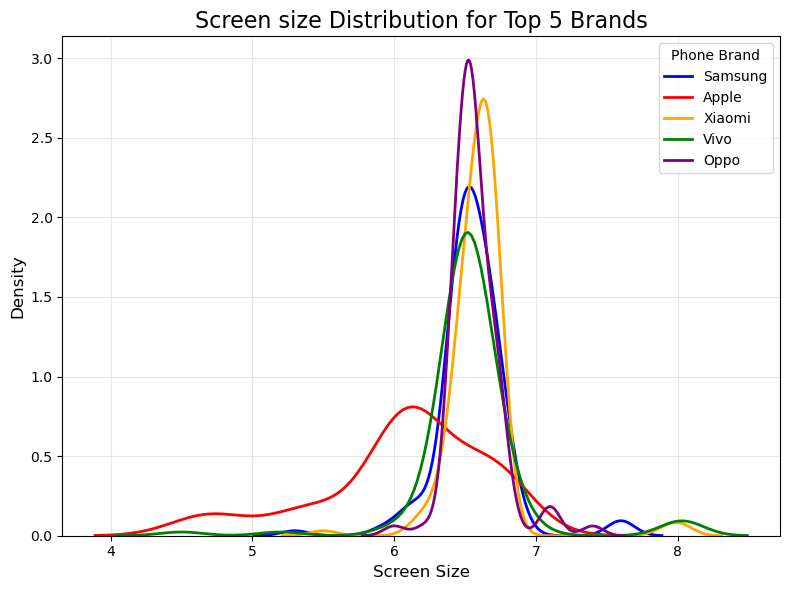

In [69]:
plt.figure(figsize=(8, 6))

# Line plot for KDE of each brand
sns.kdeplot(
    data=df[df['brand_name'] == 'samsung'],
    x='screen_size',
    label='Samsung',
    color='blue',
    linewidth=2
)
sns.kdeplot(
    data=df[df['brand_name'] == 'apple'],
    x='screen_size',
    label='Apple',
    color='red',
    linewidth=2
)
sns.kdeplot(
    data=df[df['brand_name'] == 'xiaomi'],
    x='screen_size',
    label='Xiaomi',
    color='orange',
    linewidth=2
)
sns.kdeplot(
    data=df[df['brand_name'] == 'vivo'],
    x='screen_size',
    label='Vivo',
    color='green',
    linewidth=2
)
sns.kdeplot(
    data=df[df['brand_name'] == 'oppo'],
    x='screen_size',
    label='Oppo',
    color='purple',
    linewidth=2
)

# Add titles, labels, and legend
plt.title("Screen size Distribution for Top 5 Brands", fontsize=16)
plt.xlabel("Screen Size", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(title="Phone Brand", loc='upper right')
plt.grid(alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

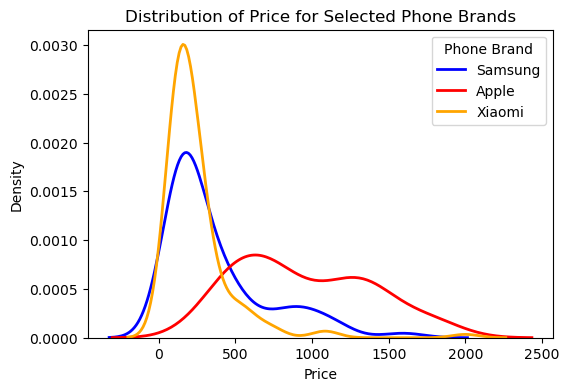

In [70]:
plt.figure(figsize=(6, 4))

# Line plot for each brand
sns.kdeplot(data=df[df['brand_name'] == 'samsung'], x='price', label='Samsung', color='blue', linewidth=2)
sns.kdeplot(data=df[df['brand_name'] == 'apple'], x='price', label='Apple', color='red', linewidth=2)
sns.kdeplot(data=df[df['brand_name'] == 'xiaomi'], x='price', label='Xiaomi', color='orange', linewidth=2)

# Add title, labels, and legend
plt.title("Distribution of Price for Selected Phone Brands")
plt.xlabel("Price")
plt.ylabel("Density")
plt.legend(title="Phone Brand")
plt.show()

> ### 7. Hitmap

In [71]:
def plot_heatmap_rear(data, title):
    # Adjust bins for Rear Camera Resolution and Price
    bins_x = np.linspace(data['primary_camera_rear'].min(), data['primary_camera_rear'].max(), 8)  # Rear Camera bins
    bins_y = np.linspace(data['price'].min(), data['price'].max(), 8)  # Price bins

    # Create a copy of the data to avoid SettingWithCopyWarning
    data = data.copy()

    # Bin the data
    data['x_bin'] = pd.cut(data['primary_camera_rear'], bins=bins_x, labels=np.round(bins_x[:-1], 2))
    data['y_bin'] = pd.cut(data['price'], bins=bins_y, labels=np.round(bins_y[:-1], 2))

    # Group by bins and count occurrences
    heatmap_data = data.groupby(['x_bin', 'y_bin'], observed=True).size().unstack(fill_value=0)

    # Plot the heatmap
    plt.figure(figsize=(8, 4))
    sns.heatmap(
        heatmap_data, cmap='Oranges', cbar_kws={'label': 'Count'}, annot=True, fmt='d', linewidths=0.5
    )
    
    # Add labels and title
    plt.title(title, fontsize=16)
    plt.xlabel("Rear Camera Resolution (MegaPixel)")
    plt.ylabel("Price (USD)")
    plt.xticks(rotation=0)
    plt.yticks(rotation=30)
    plt.tight_layout()
    plt.show()


In [72]:
def plot_heatmap_front(data, title):
    # Adjust bins for Front Camera Resolution and Price
    # Front Camera bins
    bins_x = np.linspace(data['primary_camera_front'].min(), data['primary_camera_front'].max(), 8)  
    bins_y = np.linspace(data['price'].min(), data['price'].max(), 8)  # Price bins

    # Create a copy of the data to avoid SettingWithCopyWarning
    data = data.copy()

    # Bin the data
    data['x_bin'] = pd.cut(data['primary_camera_front'], bins=bins_x, labels=np.round(bins_x[:-1], 2))
    data['y_bin'] = pd.cut(data['price'], bins=bins_y, labels=np.round(bins_y[:-1], 2))

    # Group by bins and count occurrences
    heatmap_data = data.groupby(['x_bin', 'y_bin'], observed=True).size().unstack(fill_value=0)

    # Plot the heatmap
    plt.figure(figsize=(8, 4))
    sns.heatmap(
        heatmap_data, cmap='Reds', cbar_kws={'label': 'Count'}, annot=True, fmt='d', linewidths=0.5
    )
    
    # Add labels and title
    plt.title(title, fontsize=16)
    plt.xlabel("Front Camera Resolution (MegaPixel)")
    plt.ylabel("Price (USD)")
    plt.xticks(rotation=0)
    plt.yticks(rotation=30)
    plt.tight_layout()
    plt.show()


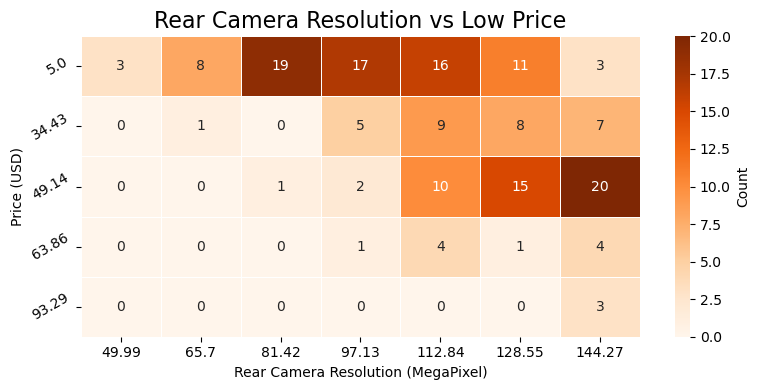

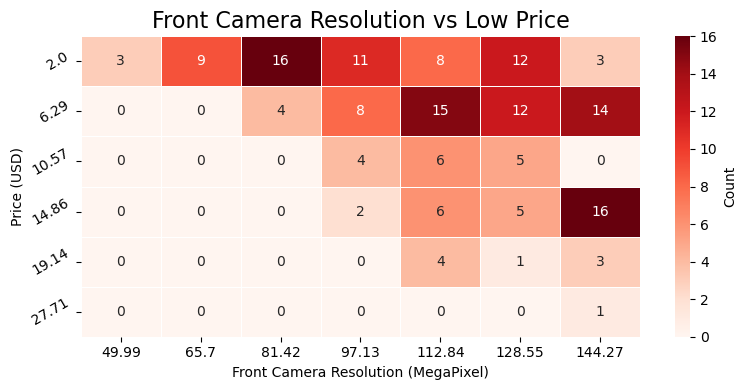

In [73]:
# Low Price Heatmaps
plot_heatmap_rear(df_low, "Rear Camera Resolution vs Low Price")
plot_heatmap_front(df_low, "Front Camera Resolution vs Low Price")

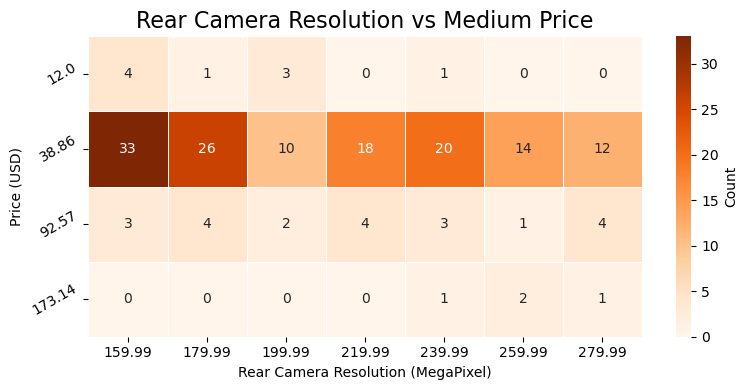

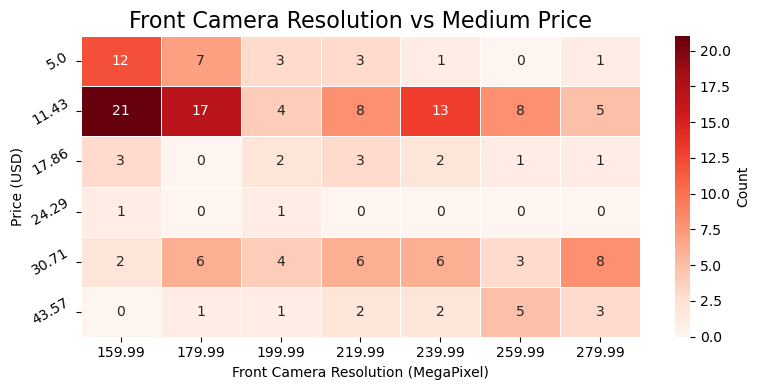

In [74]:
# Low Price Heatmaps
plot_heatmap_rear(df_mid, "Rear Camera Resolution vs Medium Price")
plot_heatmap_front(df_mid, "Front Camera Resolution vs Medium Price")

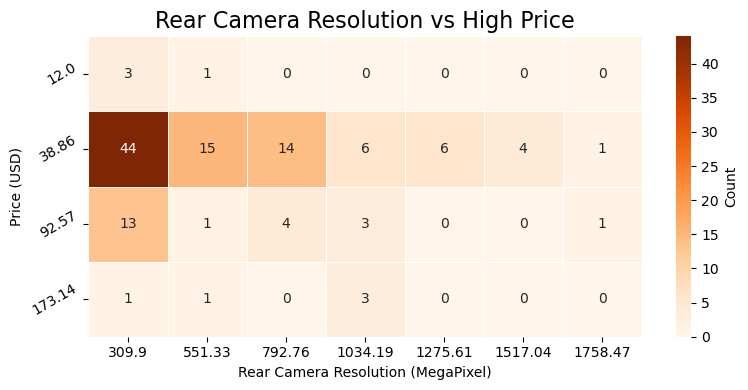

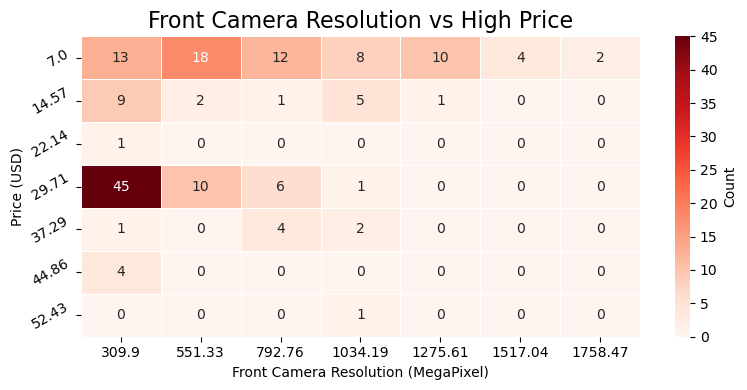

In [75]:
# Low Price Heatmaps
plot_heatmap_rear(df_high, "Rear Camera Resolution vs High Price")
plot_heatmap_front(df_high, "Front Camera Resolution vs High Price")

In [76]:
def plot_heatmap(data, title):
    # Adjust bins for PPI and Price
    bins_x = np.linspace(data['ppi'].min(), data['ppi'].max(), 8)  # PPI bins
    bins_y = np.linspace(data['price'].min(), data['price'].max(), 8)  # Price bins

    # Copy data to avoid SettingWithCopyWarning
    data = data.copy()
    data['ppi_bin'] = pd.cut(data['ppi'], bins=bins_x, labels=np.round(bins_x[:-1], 2))
    data['price_bin'] = pd.cut(data['price'], bins=bins_y, labels=np.round(bins_y[:-1], 2))

    # Group by bins and count occurrences
    heatmap_data = data.groupby(['ppi_bin', 'price_bin'], observed=True).size().unstack(fill_value=0)

    # Plot the heatmap
    plt.figure(figsize=(8, 5))
    sns.heatmap(
        heatmap_data, cmap='Purples', cbar_kws={'label': 'Count'}, annot=True, fmt='d', linewidths=0.5)
    
    # Add labels and title
    plt.title(title, fontsize=16)
    plt.xlabel("PPI (Pixels Per Inch)")
    plt.ylabel("Price")
    plt.xticks(rotation=0)
    plt.yticks(rotation=30)
    plt.tight_layout()
    plt.show()

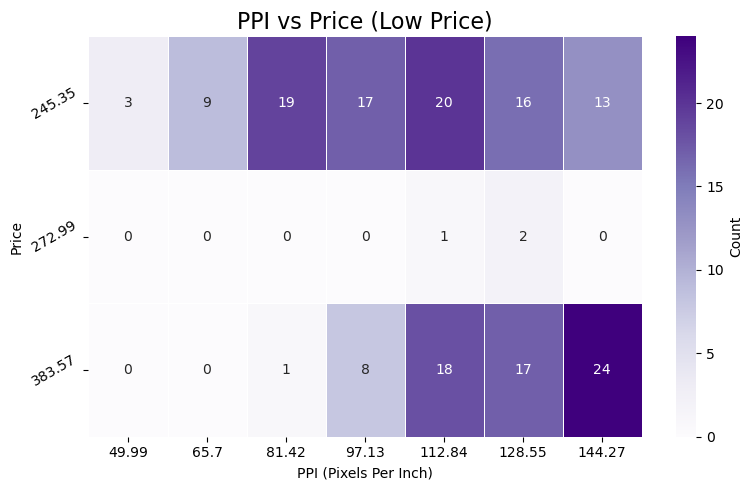

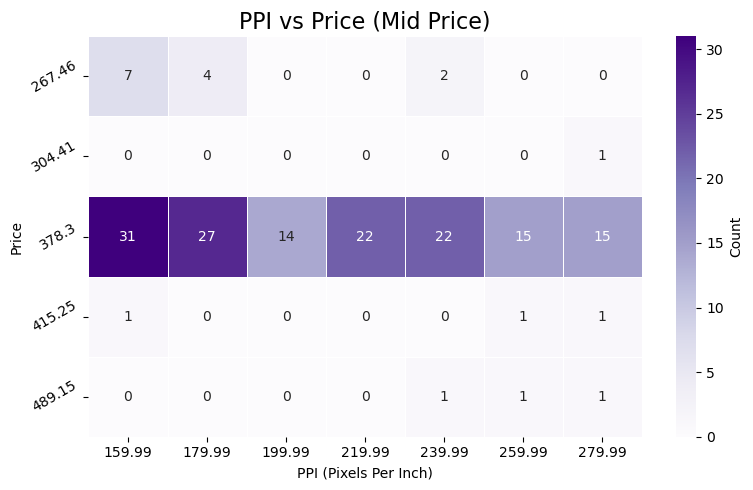

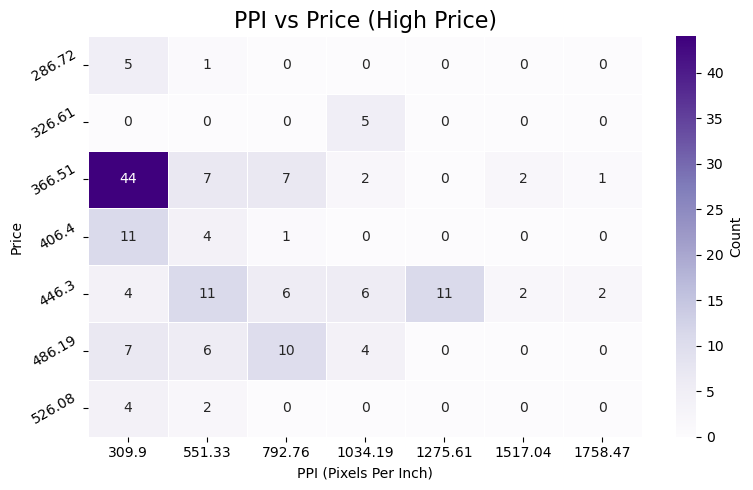

In [77]:
# Heatmap for Low price category
plot_heatmap(df_low, "PPI vs Price (Low Price)")

# Heatmap for Mid price category
plot_heatmap(df_mid, "PPI vs Price (Mid Price)")

# Heatmap for High price category
plot_heatmap(df_high, "PPI vs Price (High Price)")

### [Part 2: Advanced Visualization] - Jaemin Kim

> ### Statistics Summary

In [78]:
# Filter out categorical features
df_categorical = df[['brand_name','model','processor_brand','os']].astype(str)

# Calculate number of unique values and unique values for each feature
unique_counts = df_categorical.nunique()
unique_values = df_categorical.apply(lambda x: x.unique())

# Create new dataframe with the results
pd.DataFrame({'Number of Unique Values': unique_counts, 'Unique Values': unique_values})

,Number of Unique Values,Unique Values
brand_name,5,"[xiaomi, apple, samsung, oppo, vivo]"
model,509,"[Xiaomi Mi Mix Alpha, Apple iPhone 14 Pro Max ..."
processor_brand,9,"[snapdragon, bionic, exynos, dimensity, fusion..."
os,4,"[android, ios, other, nan]"


In [79]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

numerical_summary = df[numerical_columns].describe().T
numerical_summary

,count,mean,std,min,25%,50%,75%,max
price,509.0,3.531764e+02,341.063081,49.990000,1.399900e+02,2.199000e+02,4.199000e+02,1.999900e+03
5G_or_not,509.0,5.638507e-01,0.496394,0.000000,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
num_cores,508.0,7.759843e+00,0.751987,4.000000,8.000000e+00,8.000000e+00,8.000000e+00,8.000000e+00
processor_speed,494.0,2.497024e+00,0.453645,1.200000,2.200000e+00,2.400000e+00,2.850000e+00,3.800000e+00
battery_capacity,509.0,4.697790e+03,718.273357,1821.000000,4.500000e+03,5.000000e+03,5.000000e+03,7.000000e+03
fast_charging_available,509.0,8.703340e-01,0.336266,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
ram_capacity,509.0,6.567780e+00,2.589695,1.000000,4.000000e+00,6.000000e+00,8.000000e+00,1.600000e+01
internal_memory,509.0,1.495010e+02,120.129763,16.000000,1.280000e+02,1.280000e+02,1.280000e+02,1.024000e+03
screen_size,509.0,6.526778e+00,0.351668,4.500000,6.440000e+00,6.550000e+00,6.670000e+00,8.030000e+00
refresh_rate,509.0,8.825540e+01,27.284546,60.000000,6.000000e+01,9.000000e+01,1.200000e+02,1.440000e+02


> ### 1. Pie graphs

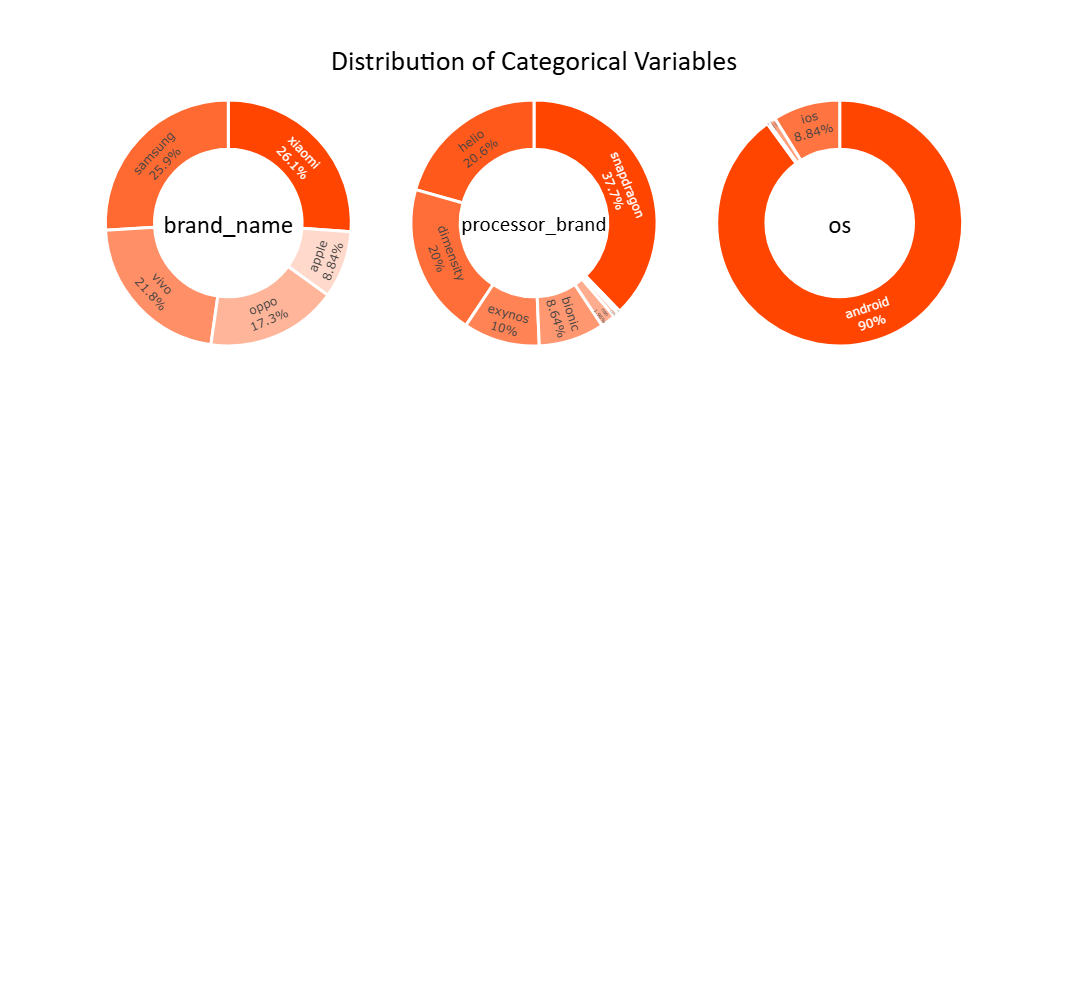

In [80]:
# Assuming df_categorical is your DataFrame containing categorical features

import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib import colors

# Ensure that df_categorical contains the correct categorical columns
df_categorical = df[['brand_name', 'processor_brand', 'os']].astype(str)

# Create the subplots 
fig = make_subplots(
    rows=3, cols=3, specs=[[{'type': 'domain'}]*3]*3, 
    vertical_spacing=0.05, horizontal_spacing=0.01
)

# Loop through all the features and add the pie chart to the subplot
for i, feature in enumerate(df_categorical.columns):
    value_counts = df_categorical[feature].value_counts()
    labels = value_counts.index.tolist()
    values = value_counts.values.tolist()

    # Define color map based on orangered color
    cmap = colors.LinearSegmentedColormap.from_list("orangered", ["orangered", "white"])
    norm = colors.Normalize(vmin=0, vmax=len(labels))
    color_list = [colors.rgb2hex(cmap(norm(i))) for i in range(len(labels))]

    # Create the pie chart
    pie_chart = go.Pie(
        labels=labels,
        values=values,
        hole=0.6,
        marker=dict(colors=color_list, line=dict(color='white', width=3)),
        textposition='inside',
        textinfo='percent+label',
        title=feature,  # Add title with the feature name
        title_font=dict(size=25, color='black', family='Calibri')
    )

    # Add the pie chart to the subplot
    if i < 8:
        row = i // 3 + 1
        col = i % 3 + 1
        fig.add_trace(pie_chart, row=row, col=col)

# Update the layout
fig.update_layout(
    showlegend=False, height=1000, width=980, 
    title={
        'text': "Distribution of Categorical Variables",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 28, 'color': 'black', 'family': 'Calibri'}
    }
)

# Show the plot
fig.show()


> ### 2. Bar chart

In [81]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib import colors

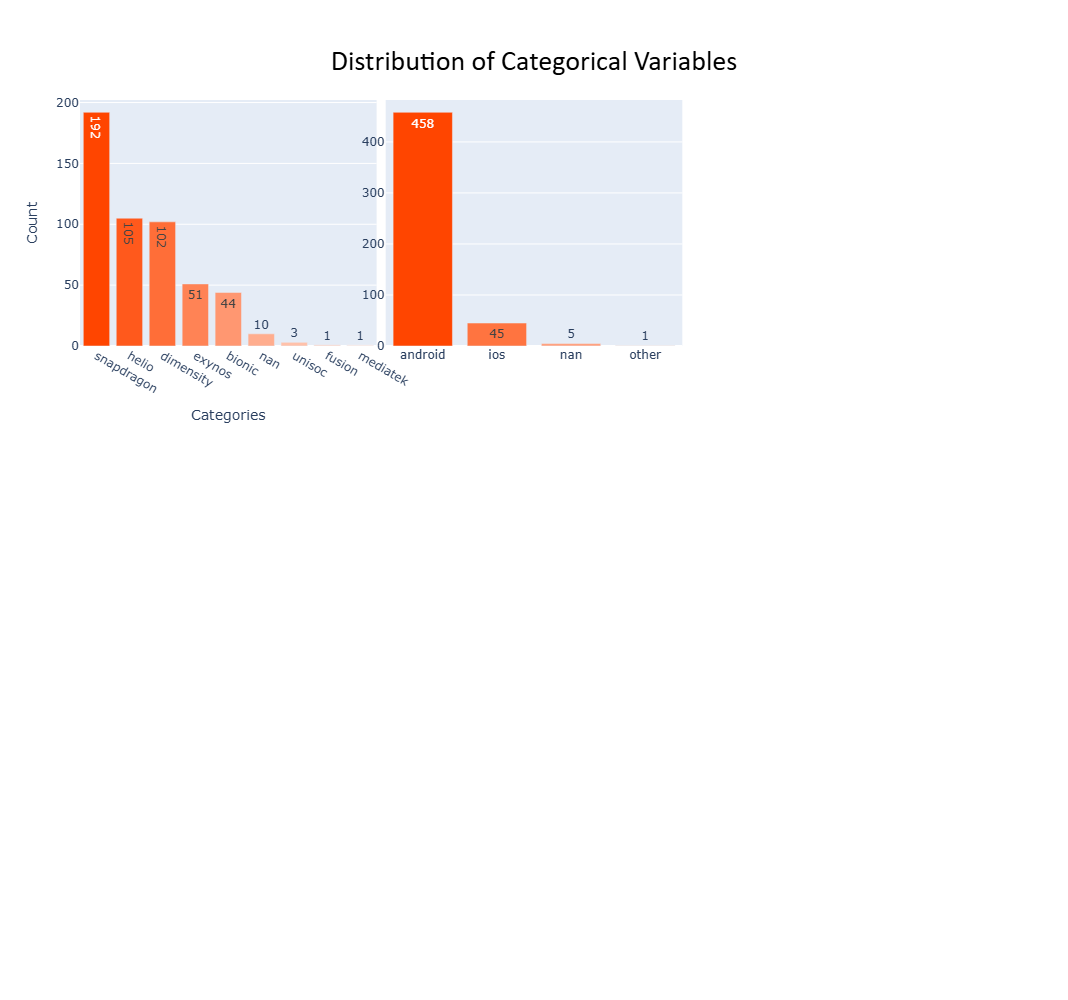

In [82]:
# Ensure that df_categorical contains the correct categorical columns
df_categorical = df[[ 'processor_brand', 'os']].astype(str)

# Create the subplots 
fig = make_subplots(
    rows=3, cols=3, specs=[[{'type': 'bar'}]*3]*3,  # Change type to 'bar' for bar graphs
    vertical_spacing=0.05, horizontal_spacing=0.01
)

# Loop through all the features and add the bar chart to the subplot
for i, feature in enumerate(df_categorical.columns):
    value_counts = df_categorical[feature].value_counts()
    labels = value_counts.index.tolist()
    values = value_counts.values.tolist()

    # Define color map based on orangered color
    cmap = colors.LinearSegmentedColormap.from_list("orangered", ["orangered", "white"])
    norm = colors.Normalize(vmin=0, vmax=len(labels))
    color_list = [colors.rgb2hex(cmap(norm(i))) for i in range(len(labels))]

    # Create the bar chart
    bar_chart = go.Bar(
        x=labels,
        y=values,
        marker=dict(color=color_list),
        text=values,
        textposition='auto',
        name=feature  # Name the trace with the feature name
    )

    # Add the bar chart to the subplot
    if i < 8:
        row = i // 3 + 1
        col = i % 3 + 1
        fig.add_trace(bar_chart, row=row, col=col)

# Update the layout
fig.update_layout(
    showlegend=False, height=1000, width=980, 
    title={
        'text': "Distribution of Categorical Variables",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 28, 'color': 'black', 'family': 'Calibri'}
    },
    xaxis_title="Categories",  # Label for the x-axis
    yaxis_title="Count"  # Label for the y-axis
)

# Show the plot
fig.show()

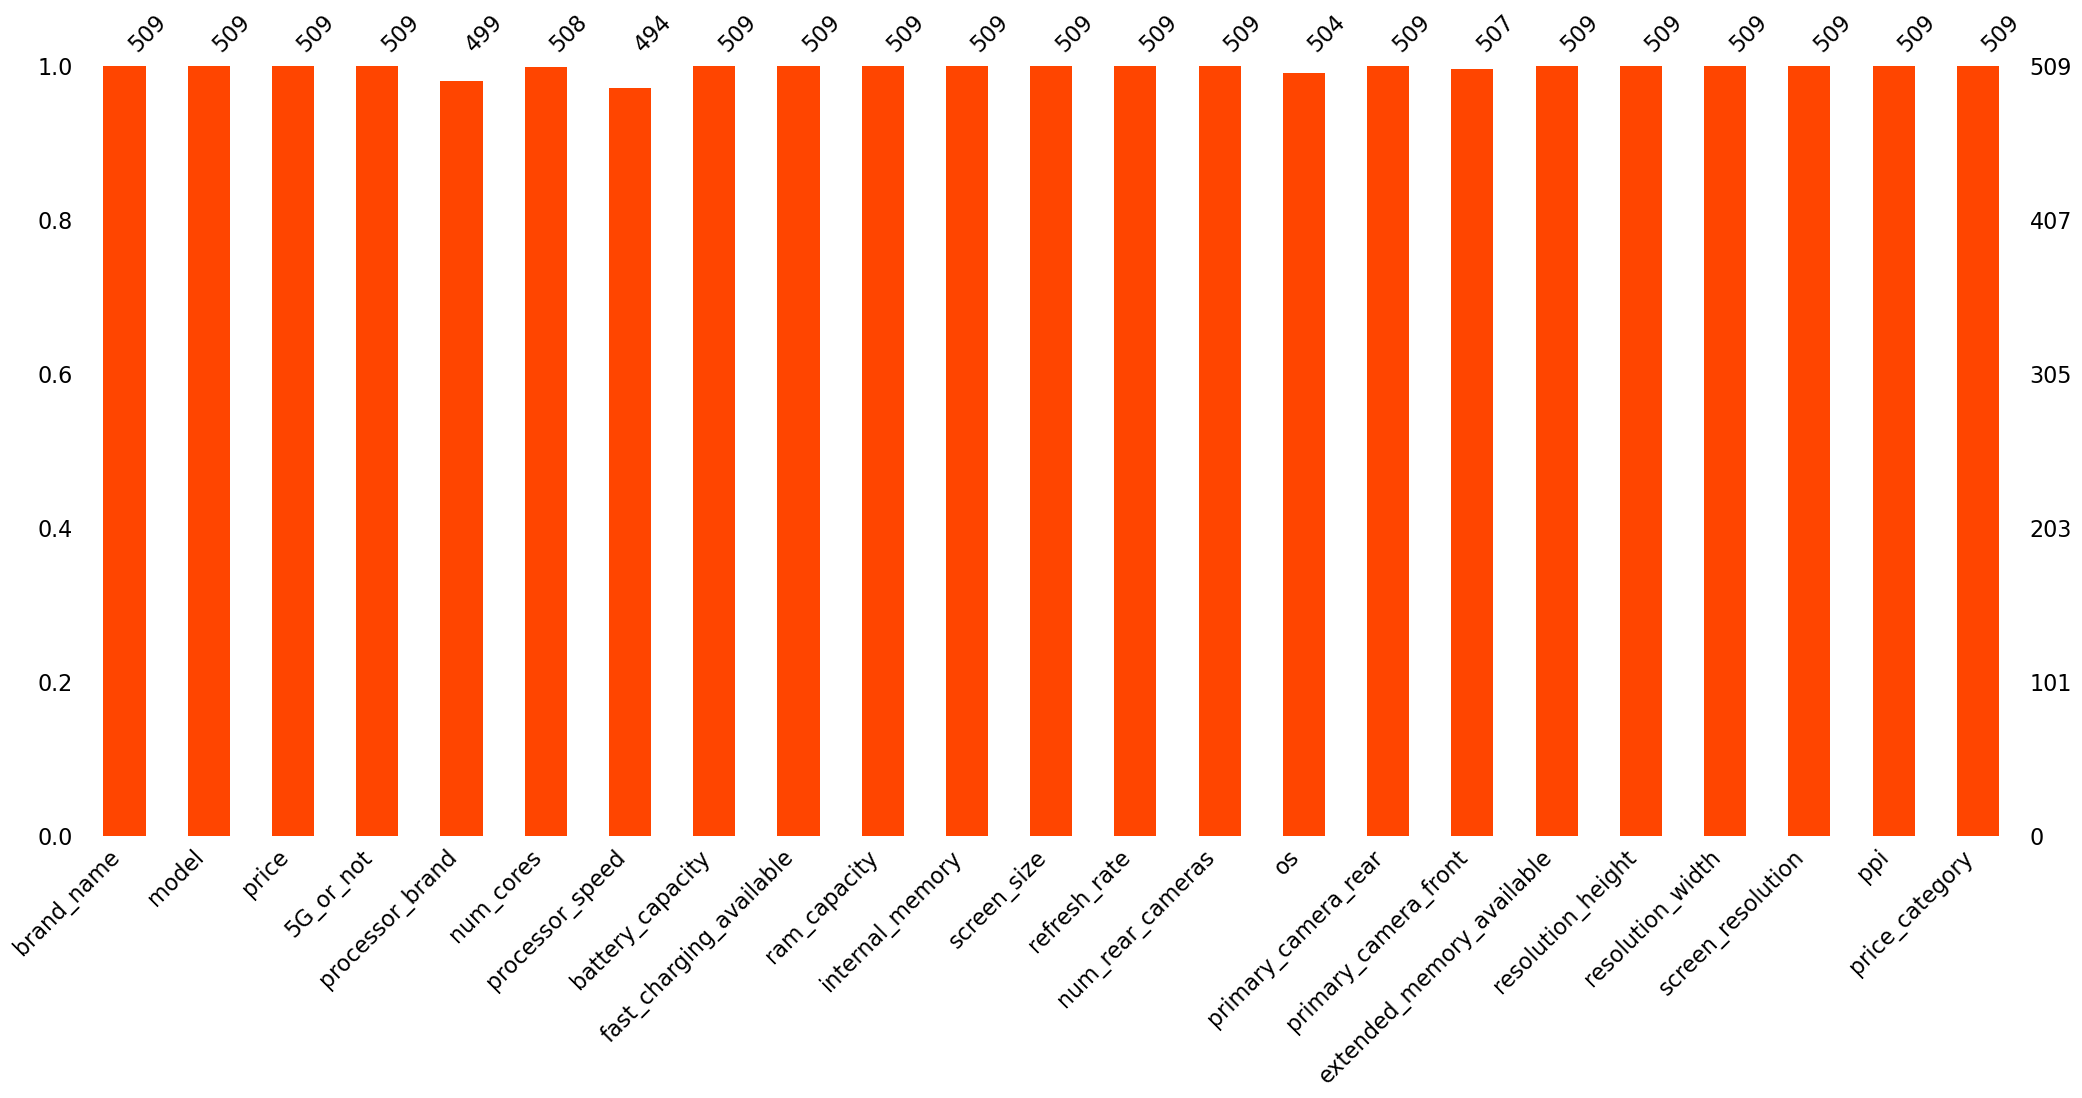

In [83]:
!pip install missingno

import missingno as msno

# Generate the missing values matrix using missingno.bar()
msno.bar(df, color='orangered')

# Display the plot
plt.show()

> ### 4. Hitmap

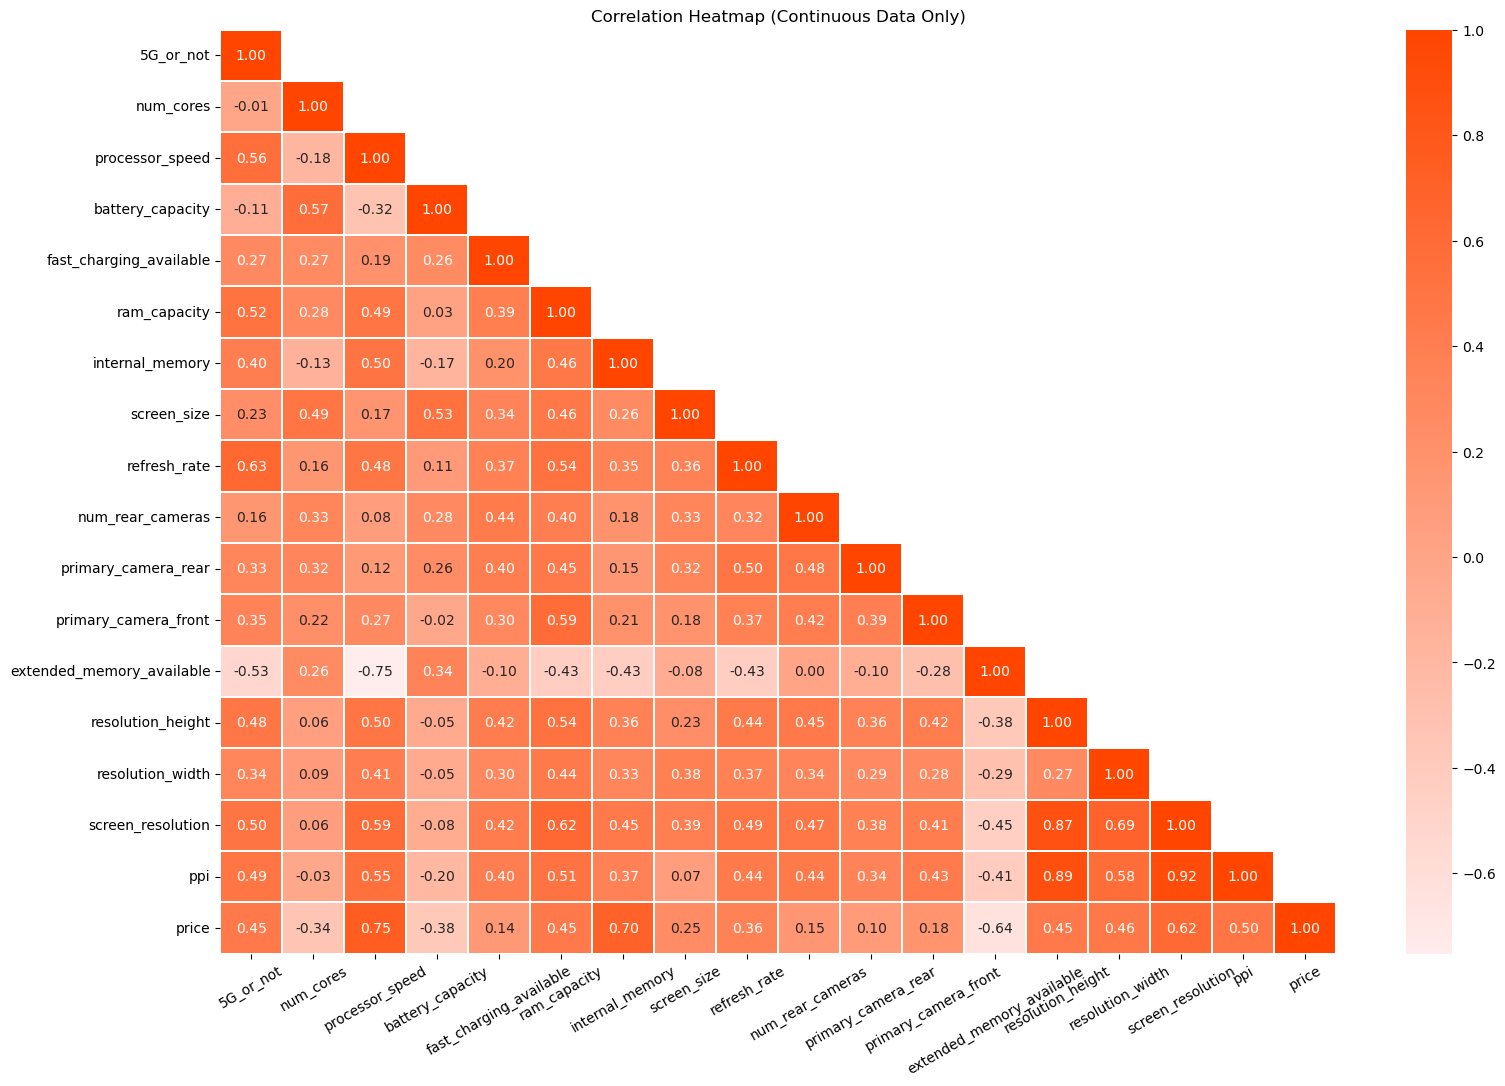

In [84]:
from matplotlib.colors import LinearSegmentedColormap
# Define a colormap
orangered_cmap = LinearSegmentedColormap.from_list('orangered', ['#FFECEC', 'orangered'])

# Filter numeric columns from the DataFrame
continuous_columns = df.select_dtypes(include=['number'])

# Calculation of the Spearman correlation
target = 'price'
df_ordered = pd.concat([continuous_columns.drop(target, axis=1), continuous_columns[target]], axis=1)
corr = df_ordered.corr()

# Create a mask so that we see the correlation values only once
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, 1)] = True

# Plot the heatmap correlation
plt.figure(figsize=(18, 12))
sns.heatmap(corr, mask=mask, annot=True, cmap=orangered_cmap, fmt='.2f', linewidths=0.2)
plt.title("Correlation Heatmap (Continuous Data Only)")
plt.xticks(rotation=30)
plt.show()

### [Part 3: Price Category Analysis] - Heewon Yang

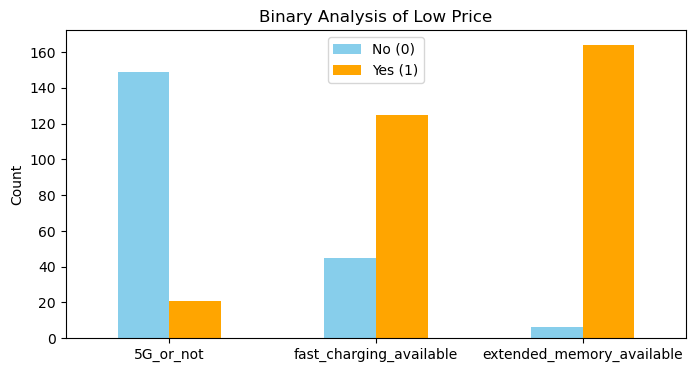

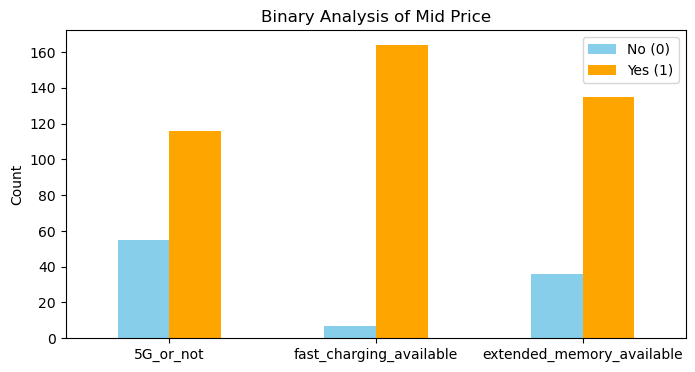

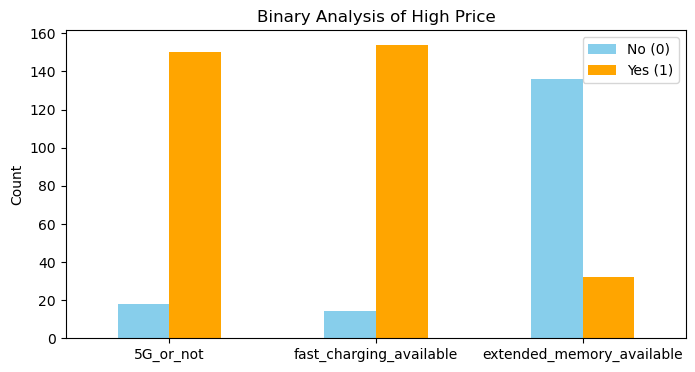

In [85]:
def plot_binary(binary, title):
    variables = binary.index
    x = list(variables)
    
    binary.plot(
        kind='bar', 
        color=['skyblue', 'orange'],
        figsize=(8, 4),
        title=title)
    
    plt.ylabel("Count")
    plt.xticks(rotation=0) 
    plt.legend(["No (0)", "Yes (1)"])
    plt.show()
    
plot_binary(binary_low, "Binary Analysis of Low Price")
plot_binary(binary_mid, "Binary Analysis of Mid Price")
plot_binary(binary_high, "Binary Analysis of High Price")

In [86]:
# Display results
print("Low Price Category Continuous Analysis:\n", conti_low)
print("\nMid Price Category Continuous Analysis:\n", conti_mid)
print("\nHigh Price Category Continuous Analysis:\n", conti__high)

Low Price Category Continuous Analysis:
 price                   1.000000
internal_memory         0.630188
primary_camera_rear     0.598361
ram_capacity            0.579865
primary_camera_front    0.471498
Name: price, dtype: float64

Mid Price Category Continuous Analysis:
 price                   1.000000
primary_camera_front    0.425614
processor_speed         0.405262
ram_capacity            0.377092
internal_memory         0.349251
Name: price, dtype: float64

High Price Category Continuous Analysis:
 price                1.000000
internal_memory      0.599889
resolution_width     0.525857
processor_speed      0.504342
screen_resolution    0.417543
Name: price, dtype: float64


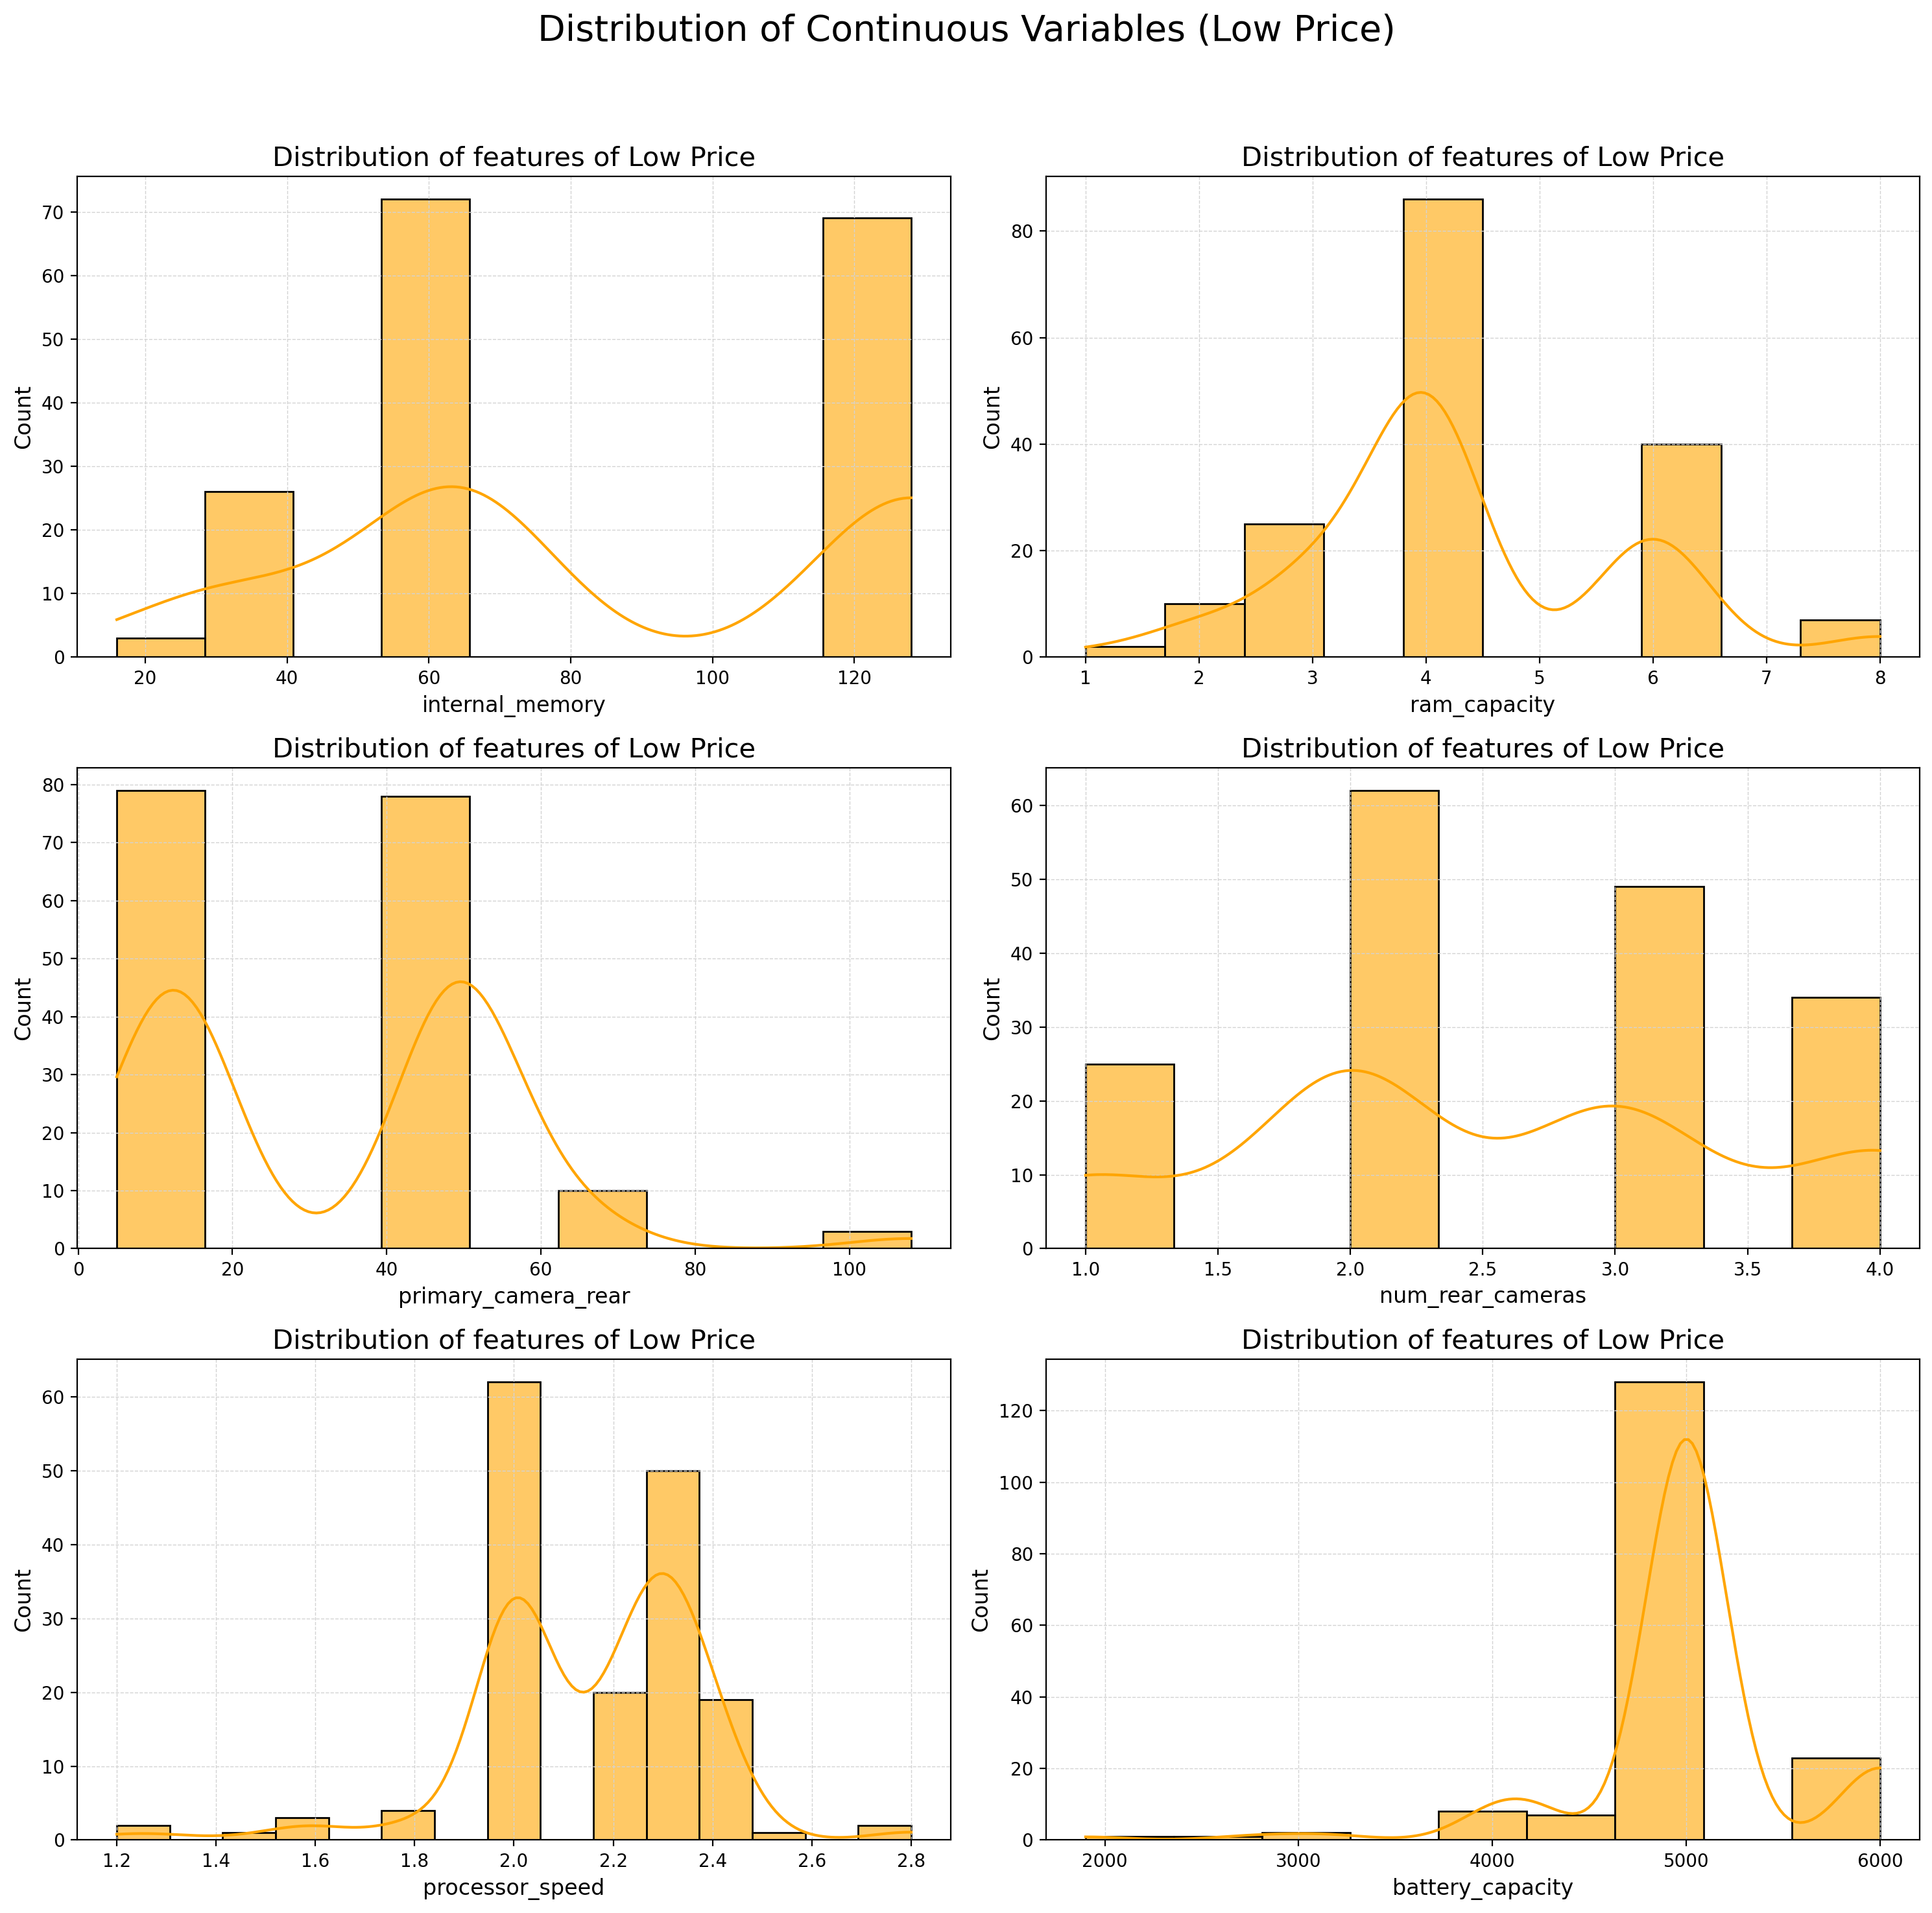

In [87]:
# Continuous variables for Low Price Category
low_continuous_columns = ['internal_memory', 'ram_capacity', 
                          'primary_camera_rear', 'num_rear_cameras', 
                          'processor_speed','battery_capacity']

# Create subplots
num_vars = len(low_continuous_columns)
ncols = 2  # Number of columns in the grid
nrows = (num_vars // ncols) + (1 if num_vars % ncols != 0 else 0)  # Calculate rows
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 5), dpi=200)
axes = axes.flatten()

# Plot each variable
for i, col in enumerate(low_continuous_columns):
    sns.histplot(df_low[col], kde=True, color='orange', alpha=0.6, ax=axes[i])
    axes[i].set_title(f"Distribution of features of Low Price", fontsize=15)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].grid(color='lightgray', linestyle='--', linewidth=0.5)

# Remove unused subplots
for j in range(len(low_continuous_columns), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout and display the plot
fig.suptitle("Distribution of Continuous Variables (Low Price)", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust the layout to fit the title
plt.show()


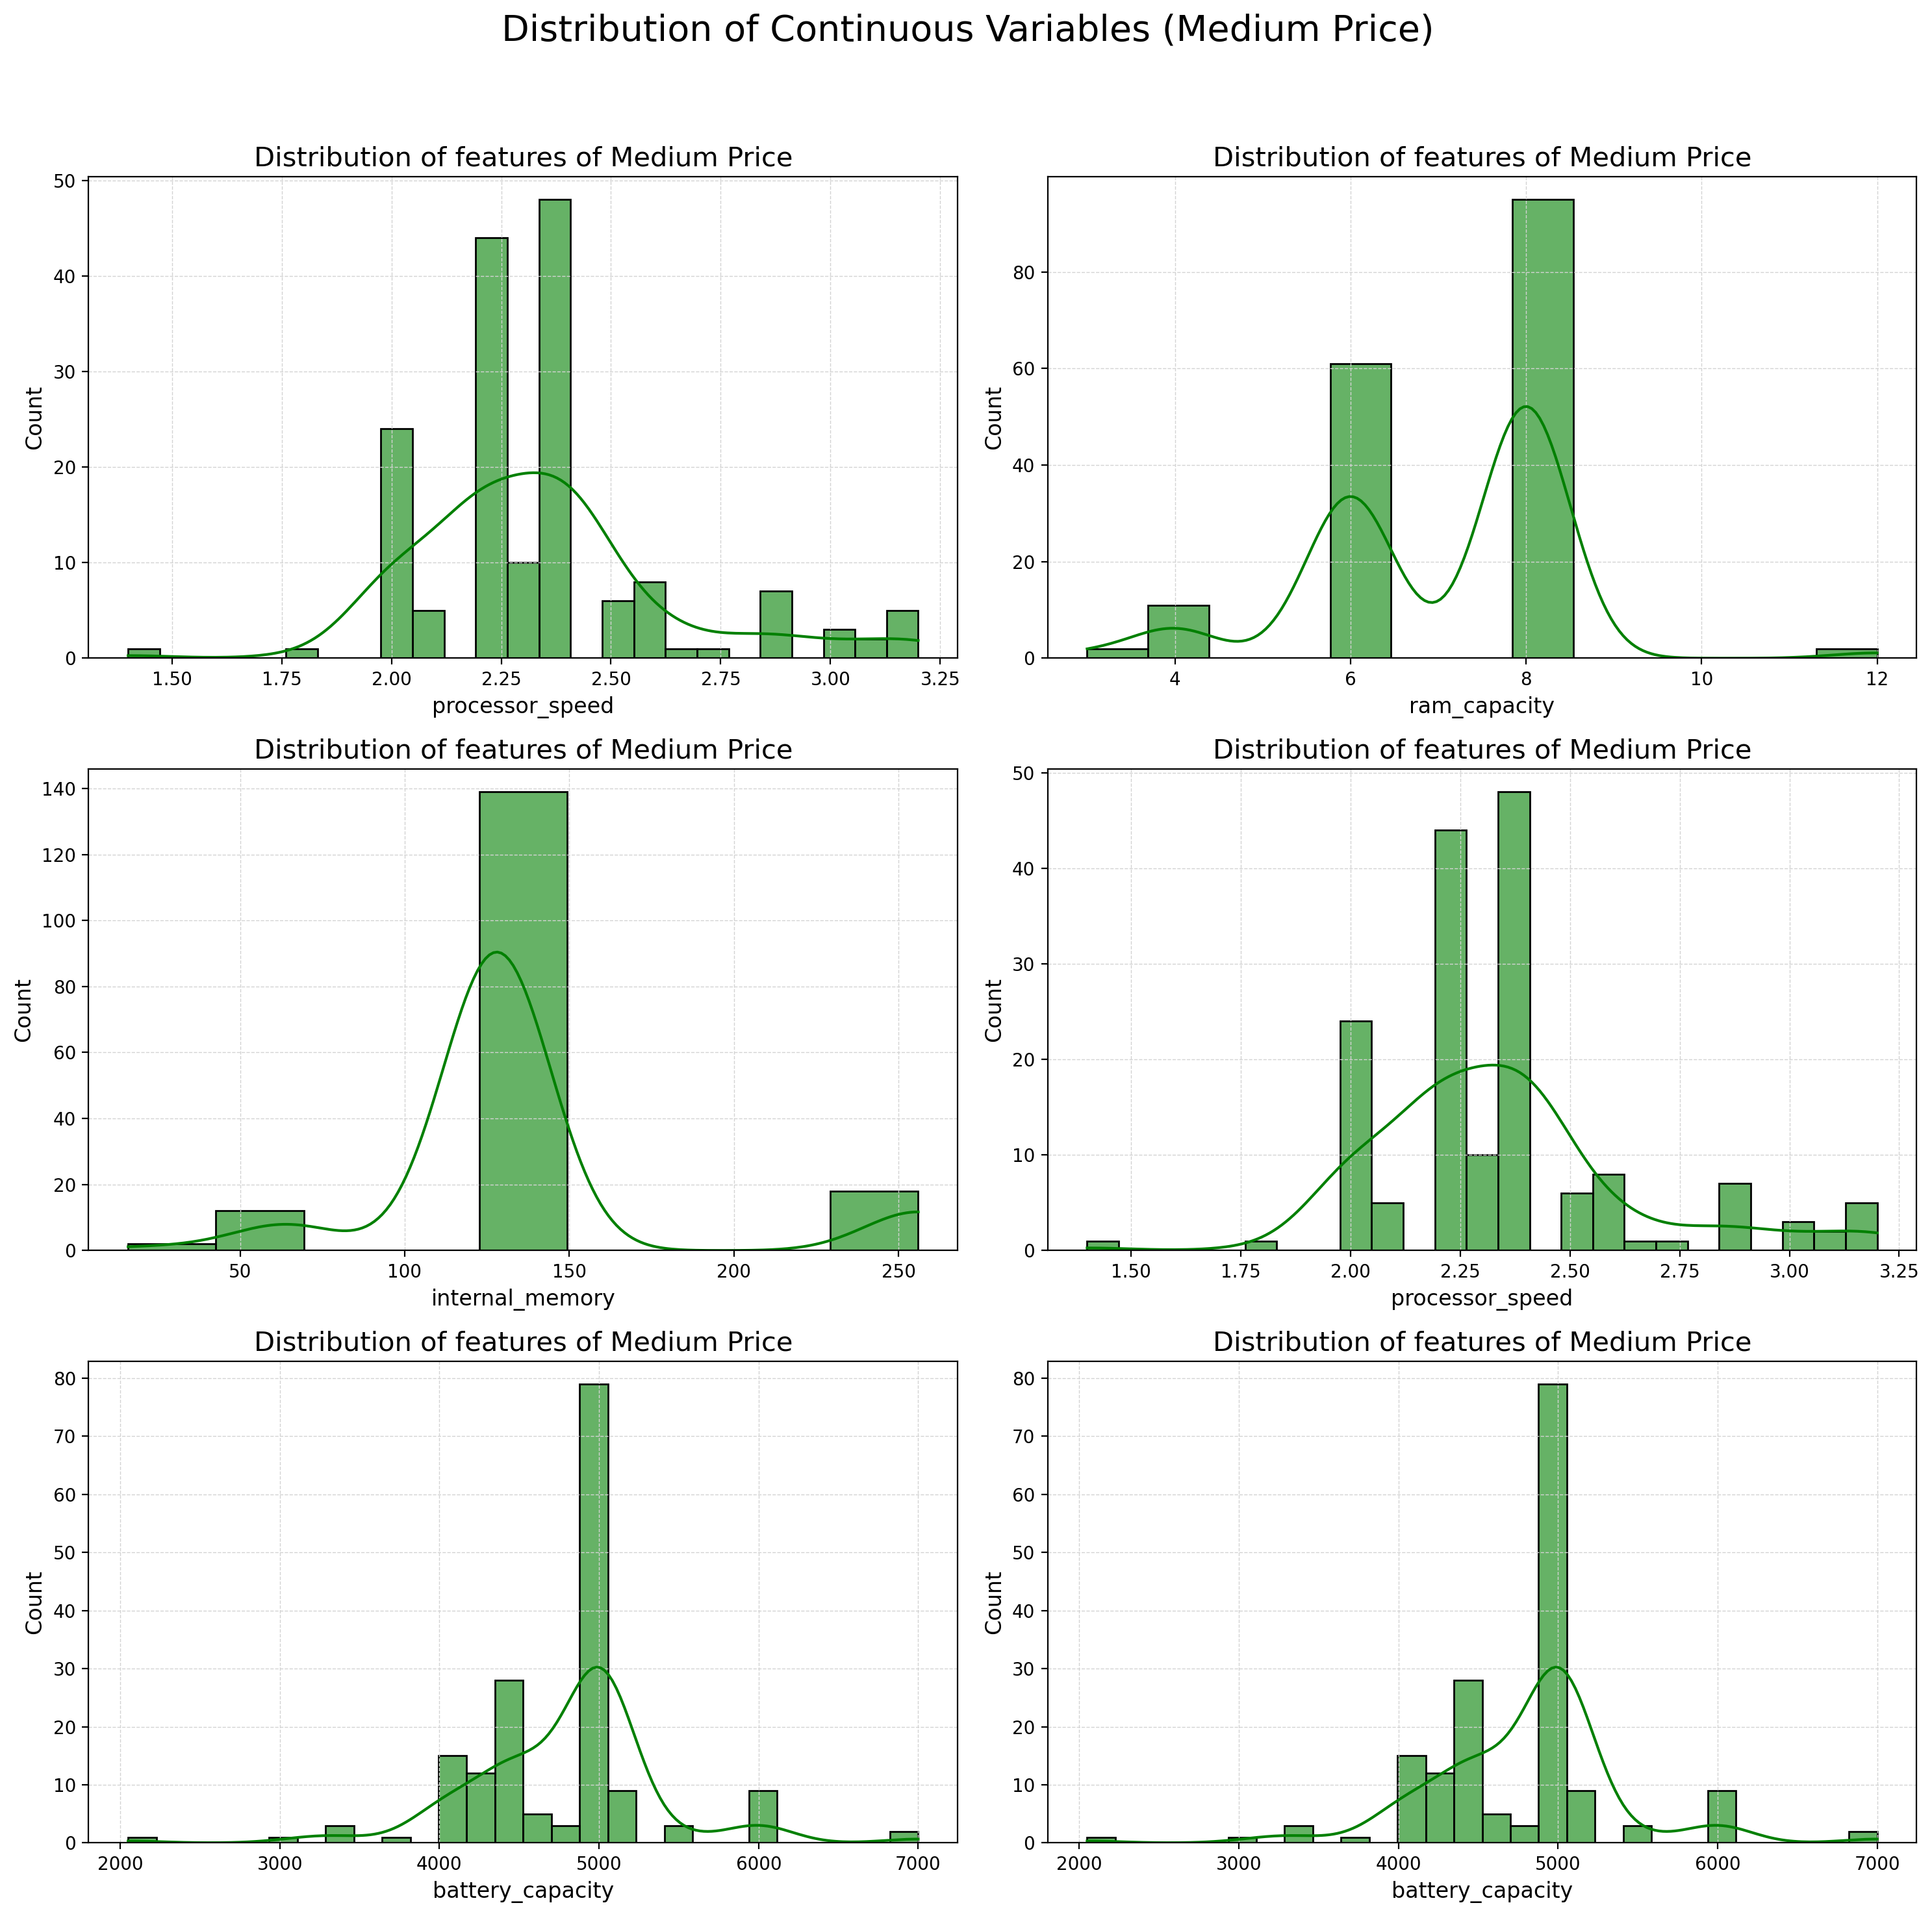

In [88]:
# Continuous variables for Low Price Category
mid_continuous_columns = ['processor_speed', 'ram_capacity', 
                          'internal_memory','processor_speed',
                          'battery_capacity','battery_capacity']

# Create subplots
num_vars = len(mid_continuous_columns)
ncols = 2  # Number of columns in the grid
nrows = (num_vars // ncols) + (1 if num_vars % ncols != 0 else 0)  # Calculate rows
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 5), dpi=200)
axes = axes.flatten()

# Plot each variable
for i, col in enumerate(mid_continuous_columns):
    sns.histplot(df_mid[col], kde=True, color='green', alpha=0.6, ax=axes[i])
    axes[i].set_title(f"Distribution of features of Medium Price", fontsize=15)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].grid(color='lightgray', linestyle='--', linewidth=0.5)

# Remove unused subplots
for j in range(len(mid_continuous_columns), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout and display the plot
fig.suptitle("Distribution of Continuous Variables (Medium Price)", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust the layout to fit the title
plt.show()

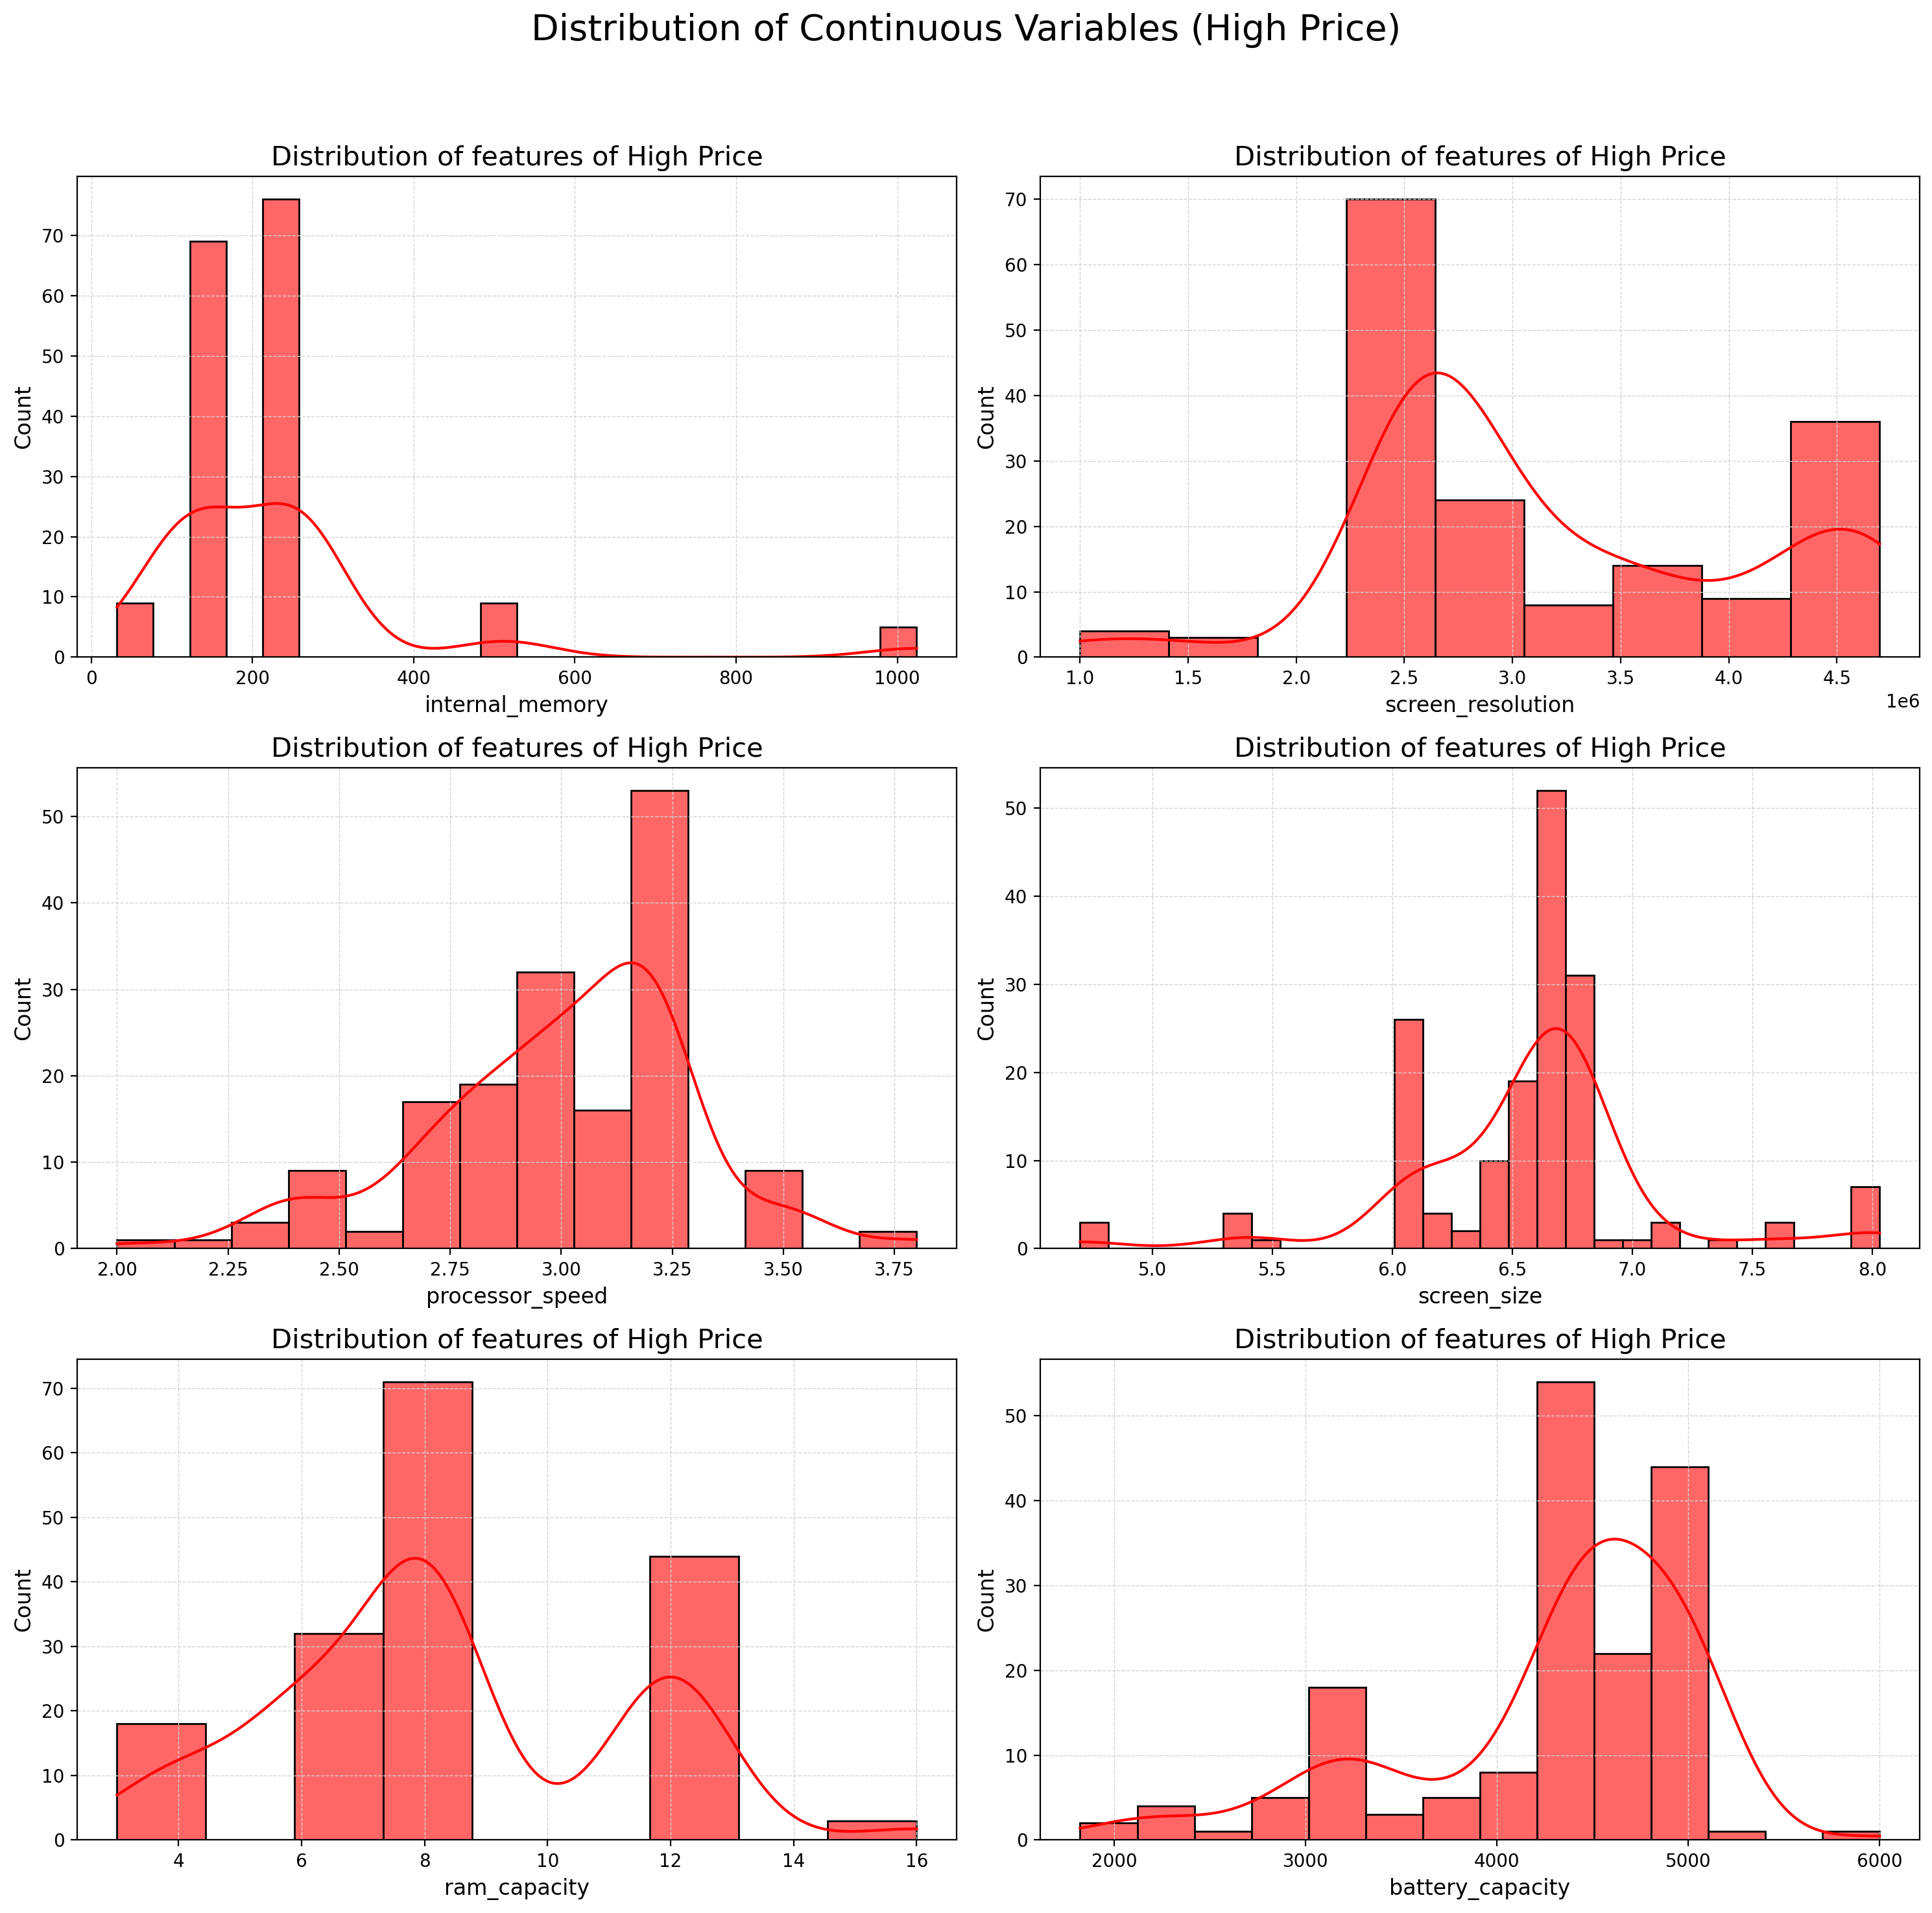

In [89]:
# Continuous variables for Low Price Category
high_continuous_columns = ['internal_memory', 'screen_resolution',
                           'processor_speed', 'screen_size', 
                           'ram_capacity','battery_capacity']

# Create subplots
num_vars = len(high_continuous_columns)
ncols = 2  # Number of columns in the grid
nrows = (num_vars // ncols) + (1 if num_vars % ncols != 0 else 0)  # Calculate rows
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 5), dpi=200)
axes = axes.flatten()

# Plot each variable
for i, col in enumerate(high_continuous_columns):
    sns.histplot(df_high[col], kde=True, color='red', alpha=0.6, ax=axes[i])
    axes[i].set_title(f"Distribution of features of High Price", fontsize=15)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].grid(color='lightgray', linestyle='--', linewidth=0.5)

# Remove unused subplots
for j in range(len(high_continuous_columns), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout and display the plot
fig.suptitle("Distribution of Continuous Variables (High Price)", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust the layout to fit the title
plt.show()

-----------

## 5. Modeling

### [Part 1: Linear Regression] - Minjun Kim

---------------------

> ### 1. Processor Speed vs Price

Intercept: -1103.9388387934341
Coefficient: 586.9611844737676
R^2 Value: 0.5348895463504022
Root Mean Squared Error (RMSE): 220.45922013805392


Text(0.5, 1.0, 'Processor Speed vs Price')

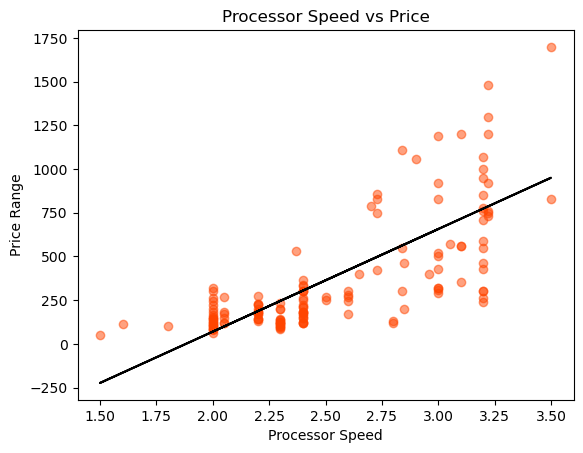

In [90]:
df_cleaned = df.dropna(subset=['processor_speed', 'price'])

x = df_cleaned[['processor_speed']]
y = df_cleaned['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

model = LinearRegression()

model.fit(x_train, y_train)

intercept = model.intercept_
slope = model.coef_

y_pred = model.predict(x_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Intercept:", intercept)
print("Coefficient:", slope[0])
print("R^2 Value:", r2)
print("Root Mean Squared Error (RMSE):", rmse)

plt.scatter(x_test['processor_speed'], y_test, color='orangered', label='Actual values', alpha= 0.5)
plt.plot(x_test['processor_speed'], y_pred, color = 'black', label='Regression line')
plt.xlabel('Processor Speed')
plt.ylabel('Price Range')
plt.title('Processor Speed vs Price')

-----------

> ### 2. Internal Memory vs Price

Intercept: 84.20206349829796
Coefficient: 0.42943171478135644
R^2 Value: 0.38984007682300525
Root Mean Squared Error (RMSE): 19.853633822756496


Text(0.5, 1.0, 'Internal Memory vs Price')

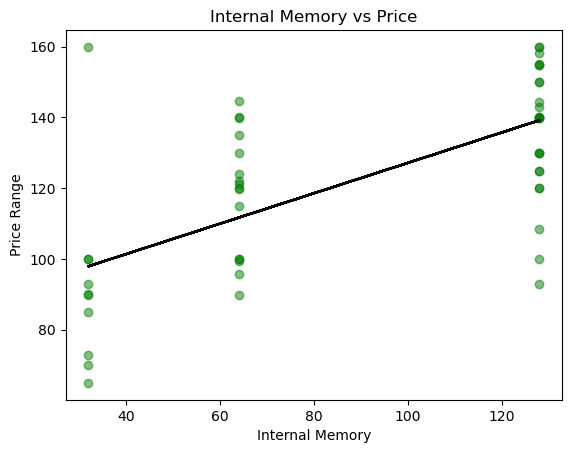

In [91]:
df_cleaned = df_low.dropna(subset=['internal_memory', 'price'])

x = df_cleaned[['internal_memory']]
y = df_cleaned['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

model = LinearRegression()

model.fit(x_train, y_train)

intercept = model.intercept_
slope = model.coef_

y_pred = model.predict(x_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Intercept:", intercept)
print("Coefficient:", slope[0])
print("R^2 Value:", r2)
print("Root Mean Squared Error (RMSE):", rmse)

plt.scatter(x_test['internal_memory'], y_test, color='green', label='Actual values', alpha= 0.5)
plt.plot(x_test['internal_memory'], y_pred, color = 'black', label='Regression line')
plt.xlabel('Internal Memory')
plt.ylabel('Price Range')
plt.title('Internal Memory vs Price')

---

> ### 3. Ram Capacity vs Price

Intercept: 393.07971620421654
Coefficient: 1.3638402564104088
R^2 Value: 0.27205504706522343
Root Mean Squared Error (RMSE): 289.42513035385656


Text(0.5, 1.0, 'RAM vs Price')

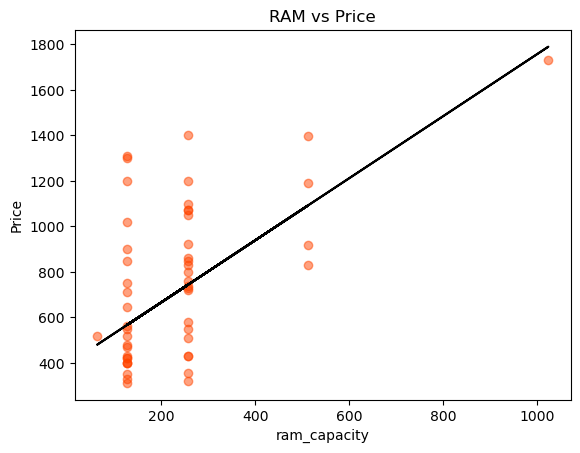

In [92]:
df_cleaned = df_high.dropna(subset=['internal_memory', 'price'])

x = df_cleaned[['internal_memory']]
y = df_cleaned['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

model = LinearRegression()

model.fit(x_train, y_train)

intercept = model.intercept_
slope = model.coef_

y_pred = model.predict(x_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Intercept:", intercept)
print("Coefficient:", slope[0])
print("R^2 Value:", r2)
print("Root Mean Squared Error (RMSE):", rmse)

plt.scatter(x_test['internal_memory'], y_test, color = 'orangered', label='Actual values', alpha = 0.5)
plt.plot(x_test['internal_memory'], y_pred, color = 'black', label='Regression line')
plt.xlabel('ram_capacity')
plt.ylabel('Price')
plt.title('RAM vs Price')

-------

> ### 4. PPI vs Price

Intercept: -565.1964592444641
Coefficient: 2.3362111158794012
R^2 Value: 0.1574462104676121
Root Mean Squared Error (RMSE): 372.6032089876153


Text(0.5, 1.0, 'Pixels Per Inch (PPI) vs Price')

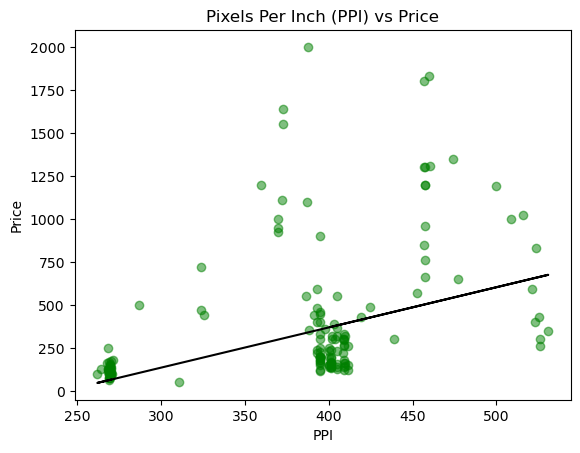

In [93]:
df_cleaned = df.dropna(subset=['ppi', 'price'])

x = df_cleaned[['ppi']]
y = df_cleaned['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

model = LinearRegression()

model.fit(x_train, y_train)

intercept = model.intercept_
slope = model.coef_

y_pred = model.predict(x_test)


r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Intercept:", intercept)
print("Coefficient:", slope[0])
print("R^2 Value:", r2)
print("Root Mean Squared Error (RMSE):", rmse)

plt.scatter(x_test['ppi'], y_test, color = 'green', label='Actual values', alpha = 0.5)
plt.plot(x_test['ppi'], y_pred, color = 'black', label='Regression line')
plt.xlabel('PPI')
plt.ylabel('Price')
plt.title('Pixels Per Inch (PPI) vs Price')

-------

> ### 5. Screen Resolution vs Price

Intercept: -188.78327295316353
Coefficient: 0.000220520635086621
R^2 Value: 0.41883723422687846
Root Mean Squared Error (RMSE): 254.90587285734648


Text(0.5, 1.0, 'Screen Resolution vs Price')

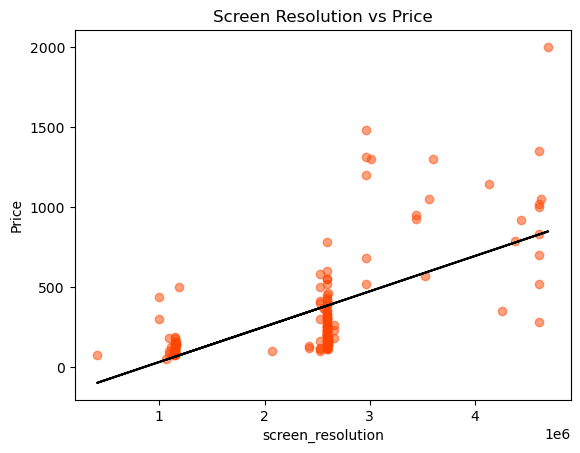

In [94]:
df_cleaned = df.dropna(subset=['screen_resolution', 'price'])

x = df_cleaned[['screen_resolution']]
y = df_cleaned['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

model = LinearRegression()

model.fit(x_train, y_train)

intercept = model.intercept_
slope = model.coef_

y_pred = model.predict(x_test)


r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Intercept:", intercept)
print("Coefficient:", slope[0])
print("R^2 Value:", r2)
print("Root Mean Squared Error (RMSE):", rmse)

plt.scatter(x_test['screen_resolution'], y_test, color = 'orangered', label='Actual values', alpha = 0.5)
plt.plot(x_test['screen_resolution'], y_pred, color = 'black', label='Regression line')
plt.xlabel('screen_resolution')
plt.ylabel('Price')
plt.title('Screen Resolution vs Price')

----------

> ### 6. Screen Size vs Price

Intercept: -1017.634353672507
Coefficient: 210.6875909369482
R^2 Value: 0.07457756096943269
Root Mean Squared Error (RMSE): 328.35376245479245


Text(0.5, 1.0, 'Screen Size vs Price')

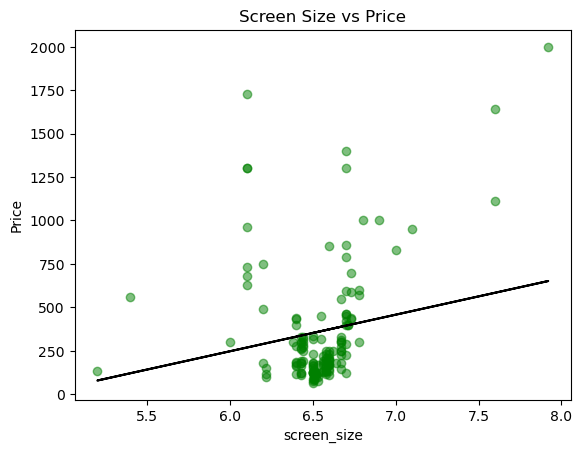

In [95]:
df_cleaned = df.dropna(subset=['screen_size', 'price'])

x = df_cleaned[['screen_size']]
y = df_cleaned['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

model = LinearRegression()

model.fit(x_train, y_train)

intercept = model.intercept_
slope = model.coef_

y_pred = model.predict(x_test)


r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Intercept:", intercept)
print("Coefficient:", slope[0])
print("R^2 Value:", r2)
print("Root Mean Squared Error (RMSE):", rmse)

plt.scatter(x_test['screen_size'], y_test, color = 'green', label='Actual values', alpha = 0.5)
plt.plot(x_test['screen_size'], y_pred, color = 'black', label='Regression line')
plt.xlabel('screen_size')
plt.ylabel('Price')
plt.title('Screen Size vs Price')

> ### Price Category (Low, Mid, High)

------

Intercept: 82.86538795913928
Coefficient: 8.7254488154749
R^2 Value: 0.44456645337222567
Root Mean Squared Error (RMSE): 20.905791927819244


Text(0.5, 1.0, 'RAM Capacity vs Price (LOW)')

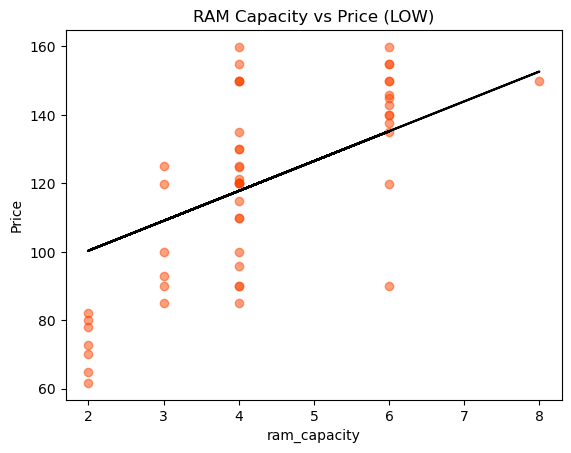

In [65]:
df_cleaned = df_low.dropna(subset=['ram_capacity', 'price'])

x = df_cleaned[['ram_capacity']]
y = df_cleaned['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

model = LinearRegression()

model.fit(x_train, y_train)

intercept = model.intercept_
slope = model.coef_

y_pred = model.predict(x_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Intercept:", intercept)
print("Coefficient:", slope[0])
print("R^2 Value:", r2)
print("Root Mean Squared Error (RMSE):", rmse)

plt.scatter(x_test['ram_capacity'], y_test, color = 'orangered', label='Actual values', alpha = 0.5)
plt.plot(x_test['ram_capacity'], y_pred, color = 'black', label='Regression line')
plt.xlabel('ram_capacity')
plt.ylabel('Price')
plt.title('RAM Capacity vs Price (LOW)')

Intercept: 114.35289543657093
Coefficient: 47.013628581764074
R^2 Value: 0.3213264757826382
Root Mean Squared Error (RMSE): 33.113606598830614


Text(0.5, 1.0, 'Processor Speed vs Price (MID) ')

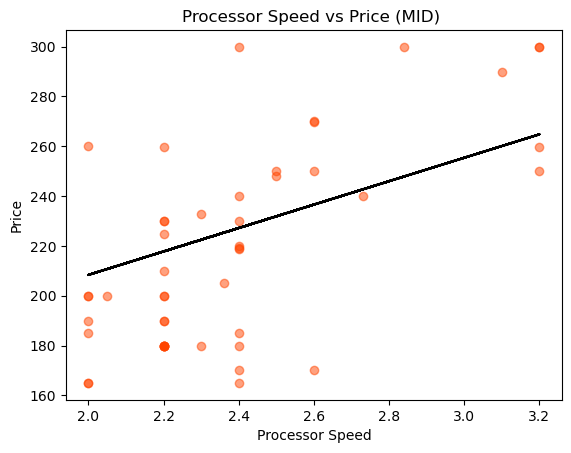

In [62]:
df_cleaned = df_mid.dropna(subset=['processor_speed', 'price'])

x = df_cleaned[['processor_speed']]
y = df_cleaned['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

model = LinearRegression()

model.fit(x_train, y_train)

intercept = model.intercept_
slope = model.coef_

y_pred = model.predict(x_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Intercept:", intercept)
print("Coefficient:", slope[0])
print("R^2 Value:", r2)
print("Root Mean Squared Error (RMSE):", rmse)

plt.scatter(x_test['processor_speed'], y_test, color='orangered', label='Actual values', alpha= 0.5)
plt.plot(x_test['processor_speed'], y_pred, color = 'black', label='Regression line')
plt.xlabel('Processor Speed')
plt.ylabel('Price')
plt.title('Processor Speed vs Price (MID) ')

Intercept: -985.056193713243
Coefficient: 570.4065028292696
R^2 Value: 0.3243062890844647
Root Mean Squared Error (RMSE): 336.0380213294364


Text(0.5, 1.0, 'Processor Speed vs Price (HIGH)')

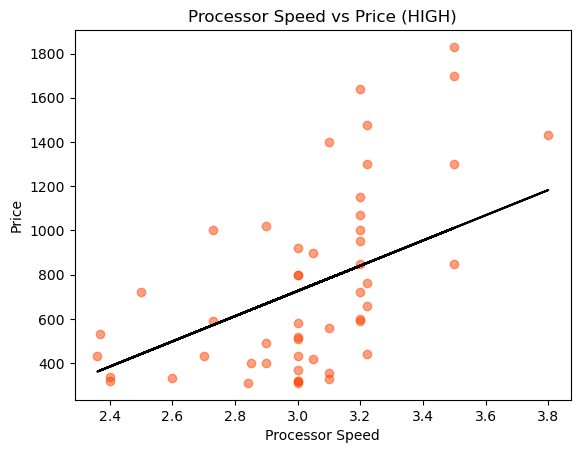

In [52]:
df_cleaned = df_high.dropna(subset=['processor_speed', 'price'])

x = df_cleaned[['processor_speed']]
y = df_cleaned['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

model = LinearRegression()

model.fit(x_train, y_train)

intercept = model.intercept_
slope = model.coef_

y_pred = model.predict(x_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Intercept:", intercept)
print("Coefficient:", slope[0])
print("R^2 Value:", r2)
print("Root Mean Squared Error (RMSE):", rmse)

plt.scatter(x_test['processor_speed'], y_test, color='orangered', label='Actual values', alpha= 0.5)
plt.plot(x_test['processor_speed'], y_pred, color = 'black', label='Regression line')
plt.xlabel('Processor Speed')
plt.ylabel('Price')
plt.title('Processor Speed vs Price (HIGH)')

------

### [Part 2: Multiple Linear Regression] - Heewon Yang & Yeso Song

Processor Speed & RAM Capacity:
Intercept: -844.8850905628917
Coefficients: [405.84076698   1.27979128]
R^2 Value: 0.7016992697949309
Root Mean Squared Error (RMSE): 168.64154908826058
Adjusted R^2 Value: 0.6976129584222588


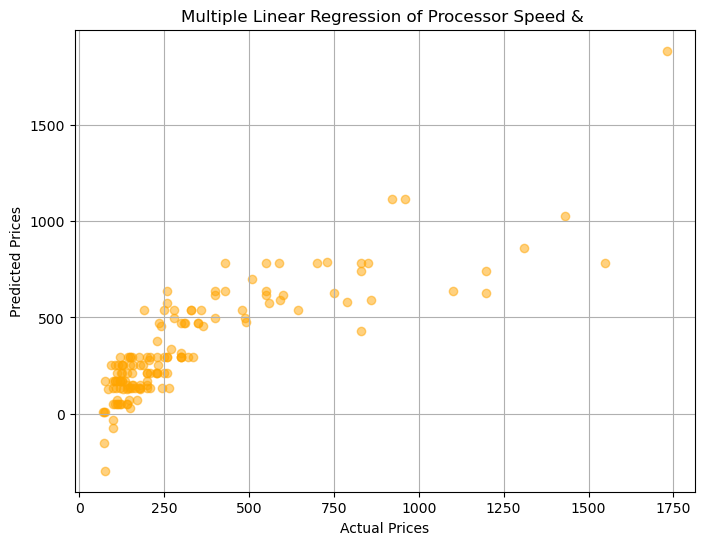

In [96]:
# 'processor_speed', 'ram_capacity'
mlr_df = df.dropna(subset=['processor_speed', 'internal_memory', 'price'])

x = mlr_df[['processor_speed', 'internal_memory']]
y = mlr_df['price']

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

# Create and train the model
mlr_model = LinearRegression()
mlr_model.fit(x_train, y_train)

# Get the intercept and coefficients
intercept = mlr_model.intercept_
coefficients = mlr_model.coef_

# Make predictions
y_pred = mlr_model.predict(x_test)

# Calculate R^2 and RMSE
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate Adjusted R^2
n = x_test.shape[0]  # Number of observations
k = x_test.shape[1]  # Number of predictors
adjusted_r2 = 1 - (1 - r2) * ((n - 1) / (n - k - 1))

# Print results
print("Processor Speed & RAM Capacity:")
print("Intercept:", intercept)
print("Coefficients:", coefficients)
print("R^2 Value:", r2)
print("Root Mean Squared Error (RMSE):", rmse)
print("Adjusted R^2 Value:", adjusted_r2)

# Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color="orange", alpha=0.5, label='Predicted vs Actual')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Multiple Linear Regression of Processor Speed & ")
plt.grid()
plt.show()

Processor Speed & RAM Capacity:
Intercept: -1082.3542979273802
Coefficients: [557.54315491   7.85137383]
R^2 Value: 0.6352493061739686
Root Mean Squared Error (RMSE): 179.5015903138964
Adjusted R^2 Value: 0.6302527213270366


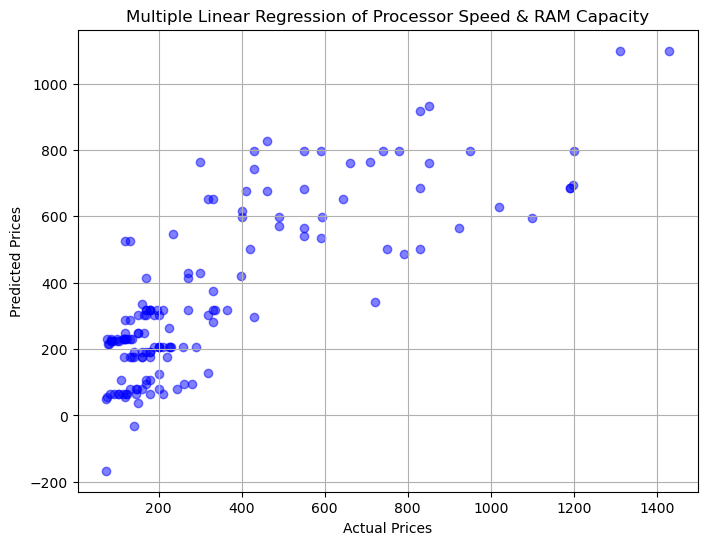

In [144]:
# 'processor_speed', 'ram_capacity'
mlr_df = df.dropna(subset=['processor_speed', 'ram_capacity', 'price'])

# Define features (x) and target variable (y)
x = mlr_df[['processor_speed', 'ram_capacity']]
y = mlr_df['price']

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

# Create and train the model
mlr_model = LinearRegression()
mlr_model.fit(x_train, y_train)

# Get the intercept and coefficients
intercept = mlr_model.intercept_
coefficients = mlr_model.coef_

# Make predictions
y_pred = mlr_model.predict(x_test)

# Calculate R^2 and RMSE
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate Adjusted R^2
n = x_test.shape[0]  # Number of observations
k = x_test.shape[1]  # Number of predictors
adjusted_r2 = 1 - (1 - r2) * ((n - 1) / (n - k - 1))

# Print results
print("Processor Speed & RAM Capacity:")
print("Intercept:", intercept)
print("Coefficients:", coefficients)
print("R^2 Value:", r2)
print("Root Mean Squared Error (RMSE):", rmse)
print("Adjusted R^2 Value:", adjusted_r2)

# Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color="blue", alpha=0.5, label='Predicted vs Actual')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Multiple Linear Regression of Processor Speed & RAM Capacity")
plt.grid()
plt.show()

> ### Low Price

Intercept: 79.39518659815899
Coefficients: [0.29349876 0.52700793]
R^2 Value: 0.5757493795874719
Root Mean Squared Error (RMSE): 17.07481086649717
Adjusted R^2 Value: 0.5580722704036165


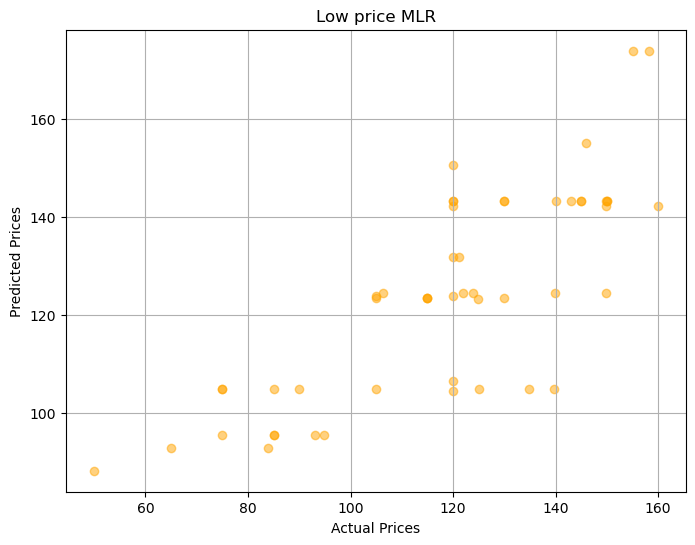

In [147]:
mlr_df = df_low.dropna(subset=['internal_memory', 'primary_camera_rear', 'price'])

# Define features (x) and target variable (y)
x = mlr_df[['internal_memory', 'primary_camera_rear']]
y = mlr_df['price']

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

# Create and train the model
mlr_model = LinearRegression()
mlr_model.fit(x_train, y_train)

# Get the intercept and coefficients
intercept = mlr_model.intercept_
coefficients = mlr_model.coef_

# Make predictions
y_pred = mlr_model.predict(x_test)

# Calculate R^2 and RMSE
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # no error

# Calculate Adjusted R^2
n = x_test.shape[0]  # Number of observations
k = x_test.shape[1]  # Number of predictors
adjusted_r2 = 1 - (1 - r2) * ((n - 1) / (n - k - 1))

# Print results
print("Intercept:", intercept)
print("Coefficients:", coefficients)
print("R^2 Value:", r2)
print("Root Mean Squared Error (RMSE):", rmse)
print("Adjusted R^2 Value:", adjusted_r2)

# Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color="orange", alpha=0.5, label='Predicted vs Actual')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Low price MLR")
plt.grid()
plt.show()

> ### Medium Price

Intercept: 64.87624048129427
Coefficients: [54.21844774  1.46903077]
R^2 Value: 0.39190758089144806
Root Mean Squared Error (RMSE): 33.80105759886687
Adjusted R^2 Value: 0.3660313077378926


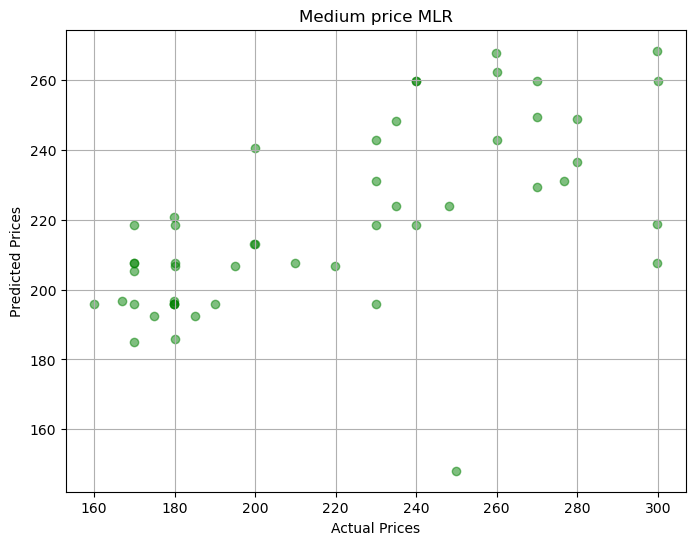

In [146]:
mlr_df = df_mid.dropna(subset=['processor_speed', 'primary_camera_front', 'price'])

# Define features (x) and target variable (y)
x = mlr_df[['processor_speed', 'primary_camera_front']]
y = mlr_df['price']

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

# Create and train the model
mlr_model = LinearRegression()
mlr_model.fit(x_train, y_train)

# Get the intercept and coefficients
intercept = mlr_model.intercept_
coefficients = mlr_model.coef_

# Make predictions
y_pred = mlr_model.predict(x_test)

# Calculate R^2 and RMSE
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) #no error

# Calculate Adjusted R^2
n = x_test.shape[0]  # Number of observations
k = x_test.shape[1]  # Number of predictors
adjusted_r2 = 1 - (1 - r2) * ((n - 1) / (n - k - 1))

# Print results
print("Intercept:", intercept)
print("Coefficients:", coefficients)
print("R^2 Value:", r2)
print("Root Mean Squared Error (RMSE):", rmse)
print("Adjusted R^2 Value:", adjusted_r2)

# Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color="green", alpha=0.5, label='Predicted vs Actual')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Medium price MLR")
plt.grid()
plt.show()

> ### High Price

In [150]:
# 'internal_memory', 'processor_speed'
df_cleaned = df_high.dropna(subset=['internal_memory', 'processor_speed', 'price'])

x = df_cleaned[['internal_memory', 'processor_speed']]
y = df_cleaned['price']

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=60)

# Train model
model = LinearRegression()
model.fit(x_train, y_train)

# Get intercept and coefficients
intercept = model.intercept_
coefficients = model.coef_

# Make predictions
y_pred = model.predict(x_test)

# Calculate R^2 and RMSE
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # no error
# rmse = mean_squared_error(y_test, y_pred, squared = False)

# Calculate Adjusted R^2
n = x_test.shape[0]  # Number of observations
k = x_test.shape[1]  # Number of predictors
adjusted_r2 = 1 - (1 - r2) * ((n - 1) / (n - k - 1))

# Print the results
print("[High Price: Processor Speed & Internal Memory]")
print("Intercept:", intercept)
print("Coefficients:", coefficients)
print("R^2 Value:", r2)
print("Root Mean Squared Error (RMSE):", rmse)
print("Adjusted R^2 Value:", adjusted_r2)

[High Price: Processor Speed & Internal Memory]
Intercept: -1043.7876092959195
Coefficients: [  1.05452159 502.23471377]
R^2 Value: 0.49816688740949
Root Mean Squared Error (RMSE): 293.2447198240844
Adjusted R^2 Value: 0.47681228687372357


In [149]:
# 'screen_size', 'processor_speed'
df_cleaned = df_high.dropna(subset=['screen_size', 'processor_speed', 'price'])

x = df_cleaned[['screen_size', 'processor_speed']]
y = df_cleaned['price']

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=60)

# Train model
model = LinearRegression()
model.fit(x_train, y_train)

# Get intercept and coefficients
intercept = model.intercept_
coefficients = model.coef_

# Make predictions
y_pred = model.predict(x_test)

# Calculate R^2 and RMSE
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # no error
#rmse = mean_squared_error(y_test, y_pred, squared = False)

# Calculate Adjusted R^2
n = x_test.shape[0]  # Number of observations
k = x_test.shape[1]  # Number of predictors
adjusted_r2 = 1 - (1 - r2) * ((n - 1) / (n - k - 1))

# Print the results
print("[High Price: Processor Speed & Screen Size]")
print("Intercept:", intercept)
print("Coefficients:", coefficients)
print("R^2 Value:", r2)
print("Root Mean Squared Error (RMSE):", rmse)
print("Adjusted R^2 Value:", adjusted_r2)

[High Price: Processor Speed & Screen Size]
Intercept: -2244.2578260192886
Coefficients: [182.70819759 582.66756682]
R^2 Value: 0.3331016595735995
Root Mean Squared Error (RMSE): 338.0495500565229
Adjusted R^2 Value: 0.30472300678949726


In [148]:
# 'internal_memory', 'screen_size'
df_cleaned = df_high.dropna(subset=['internal_memory', 'screen_size', 'price'])

x = df_cleaned[['internal_memory', 'screen_size']]
y = df_cleaned['price']

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=60)

# Train model
model = LinearRegression()
model.fit(x_train, y_train)

# Get intercept and coefficients
intercept = model.intercept_
coefficients = model.coef_

# Make predictions
y_pred = model.predict(x_test)

# Calculate R^2 and RMSE
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # no error
#rmse = mean_squared_error(y_test, y_pred, squared = False)

# Calculate Adjusted R^2
n = x_test.shape[0]  # Number of observations
k = x_test.shape[1]  # Number of predictors
adjusted_r2 = 1 - (1 - r2) * ((n - 1) / (n - k - 1))

# Print the results
print("[High Price: Internal Memory & Screen Size]")
print("Intercept:", intercept)
print("Coefficients:", coefficients)
print("R^2 Value:", r2)
print("Root Mean Squared Error (RMSE):", rmse)
print("Adjusted R^2 Value:", adjusted_r2)

[High Price: Internal Memory & Screen Size]
Intercept: -534.6775390231923
Coefficients: [  1.2012174  147.06646972]
R^2 Value: 0.3044135241110725
Root Mean Squared Error (RMSE): 293.761981440802
Adjusted R^2 Value: 0.2754307542823671
